In [6]:

# %config IPCompleter.greedy=True
import pandas as pd
import seaborn as sns
import numpy as np
import pickle
from xgboost import XGBClassifier
import random

import matplotlib as matplot
import matplotlib.pyplot as plt
# %matplotlib inline
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import warnings, os 
# warnings.filterwarnings("ignore")

# from keras import Sequential
# from keras.models import Model, load_model
# from keras.layers import *
# from keras.callbacks import ModelCheckpoint
# from keras import regularizers
from matplotlib import pyplot as plt

from sklearn.metrics import *
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA, TruncatedSVD, PCA
from sklearn.svm import LinearSVC

import xgboost
# from mlxtend.classifier import EnsembleVoteClassifier 
# import shap
import sklearn.neighbors

from deepod.models import PReNet
from collections import Counter
# from modAL.models impor ActiveLearner, Committee
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer, MinMaxScaler
import copy
from itertools import combinations, product
from sklearn.datasets import make_classification
# from alipy import ToolBox
# from alipy.utils.misc import nsmallestarg, randperm, nlargestarg

In [36]:
gks_data = [{'DoS Hulk': [(24, 0, 0)],
  'Portscan': [(39, 0.9389023797960175, 0.0),
   (169, 0.9993200582807188, 0.9912170639899623),
   (294, 0.999125789218067, 0.989522700814901)],
  'DoS GoldenEye': [(71, 0.9645699614890886, 0.3490566037735849),
   (98, 0.9940949935815148, 0.9061224489795918),
   (162, 0.9943517329910141, 0.9241379310344827),
   (195, 0.9943517329910141, 0.921146953405018),
   (234, 0.9961489088575096, 0.9479166666666666)],
  'Infiltration - Portscan': [(73, 0.9617289946576008, 0.0),
   (76, 0.9623118018455561, 0.0),
   (149, 0.999125789218067, 0.9888751545117429),
   (183, 0.9987372510927635, 0.9825970548862115)],
  'FTP-Patator': [(79, 0.9606164383561644, 0.0),
   (85, 0.9630626223091977, 0.0),
   (109, 0.9943737769080235, 0.9278996865203761),
   (168, 0.9607485775248933, 0.0),
   (213, 0.99926614481409, 0.9903536977491961),
   (258, 0.9762720156555773, 0.526829268292683),
   (263, 0.9995107632093934, 0.9936708860759493),
   (273, 0.99926614481409, 0.9901639344262295),
   (275, 1.0, 1.0)],
  'DDoS': [(117, 0.9956289460903351, 0.9392712550607287),
   (187, 0.9985342810471944, 0.9805210044590472)],
  'DoS Slowloris': [(117, 0.9622037155669443, 0.019002375296912115),
   (241, 0.9599697885196374, 0.0)],
  'SSH-Patator': [(141, 0.9609580052493438, 0.0),
   (274, 0.9625984251968503, 0.0),
   (293, 0.9665354330708661, 0.0)],
  'DoS Slowhttptest': [(266, 0.9681564245810056, 0.4)]},
 {'DDoS': [(20, 0, 0),
   (28, 0.996600291403594, 0.9560853199498118),
   (85, 0.9977659057795046, 0.9712858926342073),
   (149, 0.9990286546867412, 0.9878048780487805),
   (165, 0.9997085964060224, 0.9963811821471653),
   (181, 1.0, 1.0),
   (288, 0.99834871296746, 0.9790897908979089),
   (297, 0.9988343856240893, 0.9853658536585366)],
  'SSH-Patator': [(61, 0.9557086614173228, 0.0),
   (135, 0.9616141732283464, 0.0),
   (169, 0.9576771653543307, 0.0)],
  'DoS Hulk': [(72, 0.9630921372124851, 0.05515370705244123),
   (101, 0.9976687712481788, 0.970873786407767),
   (107, 0.9988343856240893, 0.9824561403508771),
   (114, 0.9979601748421564, 0.9715061058344641),
   (136, 0.9996114618746964, 0.9948717948717949),
   (295, 0.996600291403594, 0.9517241379310345)],
  'DoS GoldenEye': [(74, 0.9843388960205391, 0.7468879668049793),
   (133, 0.9963713158938697, 0.9511543898225224),
   (209, 0.9978177150192554, 0.9722675367047309),
   (252, 0.9978177150192554, 0.9709401709401709)],
  'DoS Slowloris': [(105, 0.9574521651560927, 0.0),
   (118, 0.9942094662638469, 0.926984126984127),
   (148, 0.9967270896273918, 0.9490196078431372),
   (149, 0.9906847935548841, 0.8762541806020067),
   (185, 0.9954682779456193, 0.9403973509933775),
   (186, 0.993705941591138, 0.9077490774907749),
   (226, 0.9974823766364552, 0.9655172413793104),
   (241, 0.9959503980964584, 0.943684377982819),
   (269, 0.9972306143001007, 0.9611307420494699)],
  'DoS Slowhttptest': [(169, 0.9871508379888269, 0.7088607594936709)],
  'Portscan': [(176, 0.9601748421563866, 0.0)],
  'Infiltration - Portscan': [(195, 0.9643516270033997, 0.005420054200542005),
   (198, 0.9989315201554152, 0.9873417721518988)]},
 {'DDoS': [(21, 0, 0),
   (46, 0.9988343856240893, 0.9853300733496333),
   (73, 0.9997085964060224, 0.9962640099626401),
   (87, 0.9985429820301117, 0.979253112033195),
   (121, 0.9970859640602234, 0.9628712871287128)],
  'Infiltration - Portscan': [(36, 0.9501699854298203, 0.003883495145631068),
   (70, 0.9577464788732394, 0.0)],
  'DoS GoldenEye': [(36, 0.9657252888318357, 0.0),
   (43, 0.9940949935815148, 0.9230769230769231),
   (50, 0.9970474967907573, 0.9544554455445544),
   (131, 0.9951219512195122, 0.9383116883116883),
   (163, 0.9983311938382542, 0.9774696707105719),
   (219, 0.9958921694480103, 0.9459459459459459),
   (228, 0.9974326059050064, 0.9649122807017544),
   (275, 0.9911424903722721, 0.8571428571428571)],
  'Portscan': [(51, 0.9576493443419135, 0.0),
   (129, 0.9972802331228752, 0.966824644549763),
   (218, 0.9959203496843128, 0.9496402877697842),
   (229, 0.999125789218067, 0.9889025893958077),
   (235, 0.9995143273433705, 0.9942196531791907)],
  'DoS Slowloris': [(59, 0.9536757301107754, 0.0),
   (131, 0.9909365558912386, 0.8695652173913043),
   (150, 0.993202416918429, 0.9018181818181819)],
  'DoS Hulk': [(62, 0.9919378338999514, 0.8798842257597684),
   (134, 0.9969888295288976, 0.9573590096286108),
   (143, 0.9987372510927635, 0.9836065573770492),
   (206, 0.9979426956867247, 0.9721658105363756),
   (211, 0.9980573093734822, 0.9754901960784313)],
  'DoS Slowhttptest': [(72, 0.964804469273743, 0.136986301369863)],
  'SSH-Patator': [(174, 0.9619422572178478, 0.0),
   (251, 0.958005249343832, 0.0),
   (259, 0.9573490813648294, 0.0)]},
 {'DoS Slowhttptest': [(45, 0, 0),
   (59, 0.9597765363128492, 0.29411764705882354),
   (66, 0.9536312849162011, 0.14432989690721648),
   (73, 0.9875703921668104, 0.8128342245989305),
   (88, 0.994413407821229, 0.9166666666666666),
   (113, 0.9921787709497206, 0.9),
   (140, 0.9960893854748604, 0.9457364341085271),
   (167, 0.9955307262569832, 0.9493670886075949),
   (171, 0.9910614525139665, 0.8974358974358975),
   (195, 0.9664804469273743, 0.5),
   (198, 0.9916201117318436, 0.8739495798319328),
   (201, 0.9920856374613161, 0.8835820895522388),
   (205, 0.9921787709497206, 0.8793103448275862),
   (271, 0.9977653631284916, 0.9714285714285714)],
  'DDoS': [(56, 0.9611849366473887, 0.00045475216007276033),
   (118, 0.9944633317144245, 0.9224489795918367),
   (214, 0.9995143273433705, 0.9938949938949939),
   (229, 0.9995143273433705, 0.9931600547195623),
   (231, 1.0, 1.0),
   (248, 0.9986401165614376, 0.9830097087378641)],
  'DoS Hulk': [(75, 0.959883438562409, 0.02364066193853428),
   (115, 0.9956289460903351, 0.9343065693430657),
   (245, 0.9962117532782905, 0.9517923362175525),
   (286, 0.9953375424963574, 0.9294117647058824)],
  'Infiltration - Portscan': [(88, 0.9613880181890424, 0.0),
   (160, 0.9611461874696454, 0.004975124378109453),
   (218, 0.9988343856240893, 0.9845758354755784),
   (264, 0.9989051256015187, 0.9855072463768116),
   (280, 0.9989315201554152, 0.9865361077111383)],
  'Portscan': [(130, 0.9998057309373483, 0.9974424552429667),
   (145, 0.9994260739040219, 0.992519277247094)],
  'DoS GoldenEye': [(153, 0.9794608472400513, 0.5604395604395604),
   (203, 0.995635430038511, 0.9322709163346613)],
  'DoS Slowloris': [(253, 0.9962235649546828, 0.9535603715170279)]},
 {'DoS Hulk': [(22, 0, 0),
   (23, 0.9986401165614376, 0.982367758186398),
   (196, 0.9918406993686255, 0.8786127167630058),
   (263, 0.9986401165614376, 0.9794117647058823),
   (269, 0.9997085964060224, 0.995850622406639)],
  'DoS GoldenEye': [(26, 0.9921694480102696, 0.8904847396768402),
   (32, 0.9854942233632863, 0.7494456762749445),
   (47, 0.9898490187384781, 0.8524923702950152),
   (55, 0.9912708600770218, 0.8798586572438163),
   (73, 0.9871630295250321, 0.7942386831275721),
   (76, 0.9898587933247753, 0.8489483747609943),
   (95, 0.9961489088575096, 0.9425287356321839),
   (166, 0.993966623876765, 0.9128014842300557),
   (173, 0.9979460847240051, 0.9728813559322034),
   (199, 0.9925545571245186, 0.8825910931174089),
   (213, 0.9969313700324365, 0.9589895524715422),
   (217, 0.9980744544287549, 0.9707602339181286),
   (230, 0.9979460847240051, 0.9719298245614035),
   (279, 0.9976893453145058, 0.9651162790697675),
   (293, 0.9975609756097561, 0.9689034369885434)],
  'FTP-Patator': [(54, 0.9417808219178082, 0.0),
   (217, 0.9765166340508806, 0.5897435897435898),
   (236, 0.9645303326810176, 0.0)],
  'DoS Slowloris': [(63, 0.9516616314199395, 0.0),
   (82, 0.9911883182275931, 0.8689138576779026)],
  'SSH-Patator': [(73, 0.9478346456692913, 0.0),
   (93, 0.9586614173228346, 0.0),
   (114, 0.9655511811023622, 0.018691588785046728),
   (115, 0.9973761106804222, 0.9667170953101362),
   (231, 0.9934383202099738, 0.9236641221374046)],
  'DoS Slowhttptest': [(113, 0.9603351955307262, 0.12345679012345678)],
  'Infiltration - Portscan': [(147, 0.9599805730937349, 0.0),
   (158, 0.9617289946576008, 0.0),
   (263, 0.9977659057795046, 0.9699346405228758)],
  'DDoS': [(189, 0.9971830985915493, 0.9625806451612903),
   (245, 0.9976687712481788, 0.96875)],
  'Portscan': [(264, 0.9960174842156386, 0.9468223086900129)]}]

In [37]:
nks_data = [{'DDoS': [(30, 0.9970859640602234, 0.9625935162094763),
   (260, 1.0, 1.0),
   (268, 0.9999028654686741, 0.998639455782313)],
  'FTP-Patator': [(36, 0.9606164383561644, 0.0),
   (106, 1.0, 1.0),
   (111, 0.9911937377690803, 0.8823529411764706),
   (117, 0.9980430528375733, 0.9736842105263158),
   (130, 0.9586148648648649, 0.008519701810436636),
   (142, 0.9987769080234834, 0.9846153846153847),
   (202, 0.9623287671232876, 0.0),
   (210, 0.961839530332681, 0.0),
   (220, 0.9975538160469667, 0.9691358024691358),
   (293, 0.9995107632093934, 0.9933333333333333)],
  'Portscan': [(48, 0.9926177756192326, 0.908433734939759),
   (76, 0.9943661971830986, 0.9276807980049875),
   (90, 0.9959736876959074, 0.9497243660418964),
   (137, 0.9985429820301117, 0.9828571428571429),
   (145, 0.9995143273433705, 0.9941656942823804),
   (214, 0.999125789218067, 0.9895470383275261),
   (243, 0.9993200582807188, 0.991494532199271),
   (265, 0.9958232151529869, 0.9473684210526315)],
  'Infiltration - Portscan': [(120, 0.9943931835239063, 0.9270534175761057),
   (158, 0.997377367654201, 0.9648894668400521)],
  'DoS Slowloris': [(138, 0.9859013091641491, 0.776),
   (240, 0.9969788519637462, 0.958041958041958)],
  'DoS Slowhttptest': [(153, 0.9710314037846888, 0.3893048128342246),
   (166, 0.9888268156424581, 0.8461538461538461)]},
 {'DDoS': [(20, 0, 0),
   (78, 0.9963088878096164, 0.9547619047619048),
   (132, 0.9989315201554152, 0.9866989117291415),
   (171, 0.9996114618746964, 0.9951807228915662),
   (292, 0.9999028654686741, 0.9987261146496815)],
  'DoS Hulk': [(29, 0.963186012627489, 0.0),
   (61, 0.9949490043710539, 0.9343434343434344),
   (78, 0.9979601748421564, 0.9731113956466069),
   (95, 0.9974040881197298, 0.9646379600673562),
   (119, 0.9972802331228752, 0.9661016949152542),
   (133, 0.9989315201554152, 0.9838945827232797),
   (224, 0.9997085964060224, 0.9961089494163424)],
  'DoS Slowloris': [(50, 0.9861530715005036, 0.8109965635738832),
   (120, 0.9921953675730111, 0.8963210702341137),
   (128, 0.9952165156092648, 0.9243027888446215),
   (224, 0.9977341389728097, 0.9712460063897763)],
  'SSH-Patator': [(67, 0.9980314960629921, 0.9739130434782609),
   (131, 0.9940944881889764, 0.926829268292683),
   (150, 0.9996719160104987, 0.9951219512195122),
   (177, 0.9990157480314961, 0.9880478087649402),
   (190, 0.9990157480314961, 0.9886792452830189),
   (197, 0.989501312335958, 0.8620689655172413),
   (235, 0.9960629921259843, 0.9444444444444444),
   (244, 0.9963910761154856, 0.9547325102880658),
   (299, 0.9983595800524935, 0.9812734082397003)],
  'DoS GoldenEye': [(71, 0.982028241335045, 0.7426470588235294),
   (202, 0.9889602053915276, 0.8154506437768241),
   (248, 0.9982498308169789, 0.9770361298224127)],
  'Infiltration - Portscan': [(93, 0.9905779504613891, 0.860431654676259)]},
 {'DDoS': [(21, 0.9946576007770762, 0.9295774647887324),
   (40, 0.9954346770276833, 0.9443786982248521),
   (80, 0.9998057309373483, 0.997275204359673),
   (184, 0.9999028654686741, 0.9987878787878788),
   (296, 0.9995143273433705, 0.9936467598475223)],
  'SSH-Patator': [(38, 0.9596456692913385, 0.0),
   (76, 0.9957349081364829, 0.9456066945606695),
   (91, 0.9957349081364829, 0.9446808510638298),
   (112, 0.9986876640419947, 0.9849624060150376),
   (169, 0.9963910761154856, 0.9547325102880658),
   (189, 0.9973753280839895, 0.9652173913043478),
   (191, 0.9957349081364829, 0.9469387755102041),
   (204, 0.9963910761154856, 0.9527896995708155),
   (235, 0.9984495199475222, 0.9806547619047619),
   (243, 0.9980314960629921, 0.9734513274336283),
   (271, 0.9977034120734908, 0.9694323144104804)],
  'DoS GoldenEye': [(54, 0.9781771501925546, 0.5990566037735849),
   (60, 0.9804878048780488, 0.6274509803921569),
   (119, 0.997175866495507, 0.9614035087719298),
   (122, 0.9951219512195122, 0.9306569343065694),
   (162, 0.9948652118100129, 0.9290780141843972),
   (186, 0.9979460847240051, 0.9726962457337884),
   (296, 0.9984595635430038, 0.9803921568627451)],
  'DoS Slowloris': [(55, 0.9891742195367573, 0.8668730650154799)],
  'Infiltration - Portscan': [(80, 0.9875667799902865, 0.8427518427518428),
   (186, 0.9987372510927635, 0.9835234474017744),
   (196, 0.9993200582807188, 0.990578734858681)],
  'Portscan': [(100, 0.9964060223409422, 0.9548229548229549),
   (133, 0.9961146187469645, 0.9518072289156626),
   (137, 0.9993200582807188, 0.9913686806411838)],
  'DoS Slowhttptest': [(155, 0.9865921787709497, 0.7692307692307693),
   (222, 0.9927374301675977, 0.8539325842696629),
   (236, 0.9754189944134078, 0.6764705882352942),
   (251, 0.994413407821229, 0.9193548387096774)],
  'DoS Hulk': [(157, 0.999125789218067, 0.9874826147426982),
   (160, 0.9988343856240893, 0.983957219251337),
   (193, 0.9992229237493929, 0.9897172236503856)]},
 {'DoS Slowloris': [(31, 0.9554380664652568, 0.0),
   (128, 0.9952165156092648, 0.9442815249266863)],
  'Infiltration - Portscan': [(46, 0.9797960174842156, 0.6450511945392492),
   (104, 0.997377367654201, 0.963855421686747),
   (146, 0.9964060223409422, 0.9560047562425684),
   (148, 0.999125789218067, 0.9889025893958077),
   (196, 0.9990286546867412, 0.9861495844875346),
   (266, 0.9974745021855269, 0.9693396226415094)],
  'DDoS': [(48, 0.9968743101849808, 0.9607799689785065),
   (190, 0.999805748090592, 0.9974613431802446)],
  'DoS Slowhttptest': [(52, 0.9675977653631285, 0.03333333333333333),
   (83, 0.9558659217877095, 0.2616822429906542),
   (90, 0.9486033519553073, 0.11538461538461539),
   (99, 0.9843575418994414, 0.7543859649122807),
   (189, 0.9826815642458101, 0.7304347826086957),
   (198, 0.988268156424581, 0.8235294117647058),
   (208, 0.9787709497206704, 0.703125),
   (223, 0.9782122905027933, 0.7111111111111111),
   (254, 0.9852366698797625, 0.7589063794531897)],
  'DoS GoldenEye': [(76, 0.9873987818822486, 0.8235870630512905),
   (110, 0.9913992297817715, 0.8662674650698603),
   (242, 0.9976893453145058, 0.9705882352941176)],
  'DoS Hulk': [(109, 0.9974745021855269, 0.9679012345679012),
   (138, 0.9996114618746964, 0.9944289693593314),
   (234, 0.9990287404529601, 0.9870557778300777),
   (281, 0.9992229237493929, 0.9903381642512077)],
  'SSH-Patator': [(137, 0.9960629921259843, 0.9487179487179487),
   (153, 0.9954976444629972, 0.9457809694793536)],
  'Portscan': [(160, 0.9965031568722681, 0.9565217391304348)],
  'FTP-Patator': [(255, 0.9995107632093934, 0.9933774834437086)]},
 {'Portscan': [(24, 0.9457017969888295, 0.0),
   (47, 0.9963088878096164, 0.9573033707865168),
   (277, 0.9992583108913514, 0.9903426074959761)],
  'SSH-Patator': [(29, 0.9583333333333334, 0.0),
   (36, 0.9550524934383202, 0.0),
   (39, 0.9622703412073491, 0.0),
   (48, 0.9953485598425666, 0.9428152492668622),
   (81, 0.9950787401574803, 0.9367088607594937),
   (124, 0.9963910761154856, 0.9547325102880658),
   (159, 0.9980314960629921, 0.9736842105263158),
   (260, 0.9993438320209974, 0.9919354838709677)],
  'DoS GoldenEye': [(38, 0.958408215661104, 0.006134969325153374),
   (115, 0.989602053915276, 0.8605851979345955),
   (226, 0.9966623876765084, 0.9488188976377953),
   (255, 0.9988446726572529, 0.9825242718446602)],
  'DoS Slowloris': [(43, 0.9617321248741189, 0.02564102564102564),
   (46, 0.9939577039274925, 0.9210526315789473),
   (52, 0.9911915438821268, 0.8791208791208791),
   (263, 0.9959718026183283, 0.9459459459459459)],
  'DoS Hulk': [(75, 0.9987372510927635, 0.9836065573770492),
   (203, 0.9955318115590093, 0.944578313253012)],
  'DDoS': [(78, 0.996600291403594, 0.958968347010551),
   (122, 0.9998057309373483, 0.9974489795918368),
   (128, 0.9987372510927635, 0.9833119383825417),
   (147, 0.9993200582807188, 0.9915151515151515),
   (225, 0.9996114618746964, 0.9950372208436724)],
  'FTP-Patator': [(136, 0.99779843444227, 0.9716088328075709),
   (292, 1.0, 1.0)],
  'Infiltration - Portscan': [(284, 0.9988343856240893, 0.9846153846153847)]}]

In [38]:
cks_data = [{'Portscan': [(32, 0, 0),
   (85, 0.9998057309373483, 0.9975550122249389),
   (151, 0.9995143273433705, 0.9938650306748467),
   (188, 0.9995143273433705, 0.9939246658566221),
   (291, 0.9997262814003797, 0.99635079458505)],
  'Infiltration - Portscan': [(52, 0.9573579407479359, 0.0),
   (91, 0.9989051256015187, 0.9854562514661037),
   (201, 0.999125789218067, 0.9881422924901185),
   (257, 0.999125789218067, 0.9896432681242808)],
  'DoS GoldenEye': [(55, 0.9644415917843389, 0.0),
   (87, 0.9892189578325905, 0.8355286578853685),
   (138, 0.9974326059050064, 0.96875),
   (225, 0.9978177150192554, 0.9712351945854484)],
  'FTP-Patator': [(63, 0.9559686888454012, 0.0),
   (149, 0.9995107632093934, 0.993421052631579),
   (159, 0.9995554765291608, 0.9939649969824985),
   (179, 0.9630626223091977, 0.0),
   (181, 0.9997553816046967, 0.9967845659163987)],
  'DoS Slowhttptest': [(134, 0.9575418994413408, 0.19148936170212766)],
  'SSH-Patator': [(163, 0.9550524934383202, 0.0)],
  'DDoS': [(212, 0.9609519184069937, 0.009852216748768473)]},
 {'DoS Hulk': [(28, 0.962408936376882, 0.04914004914004914),
   (105, 0.9994702220652509, 0.9929211892402077),
   (174, 0.9998057309373483, 0.9975728155339806)],
  'DoS Slowloris': [(46, 0.9962235649546828, 0.9454545454545454),
   (65, 0.9966825295140478, 0.9554257608361513),
   (85, 0.9959718026183283, 0.9384615384615385),
   (104, 0.9974823766364552, 0.9635036496350365),
   (106, 0.9967270896273918, 0.9584664536741214),
   (198, 0.9982376636455186, 0.9771986970684039),
   (216, 0.9974832982520362, 0.9665450121654501),
   (280, 0.9977341389728097, 0.9737609329446064),
   (281, 0.9979859013091642, 0.971830985915493)],
  'DDoS': [(61, 0.996600291403594, 0.9523809523809523),
   (187, 0.9996114618746964, 0.995085995085995),
   (208, 0.9997085964060224, 0.9960886571056062)],
  'SSH-Patator': [(115, 0.9993438320209974, 0.991869918699187),
   (141, 0.9639107611548556, 0.0),
   (165, 0.994750656167979, 0.9207920792079208),
   (234, 0.9986876640419947, 0.9838709677419355),
   (267, 0.9993438320209974, 0.9906542056074766)],
  'DoS Slowhttptest': [(120, 0.9967530820354117, 0.9579500657030223)],
  'Portscan': [(127, 0.9994171928120447, 0.9918032786885246),
   (145, 0.9993200582807188, 0.9903181189488244),
   (247, 0.9989315201554152, 0.9873417721518988)],
  'DoS GoldenEye': [(225, 0.997175866495507, 0.9619377162629758)]},
 {'SSH-Patator': [(23, 0.9612860892388452, 0.0),
   (47, 0.9550524934383202, 0.0),
   (132, 0.9996719160104987, 0.9953488372093023),
   (157, 0.9980314960629921, 0.9727272727272728),
   (166, 0.9990157480314961, 0.9878542510121457),
   (199, 0.9993438320209974, 0.9906542056074766),
   (200, 0.9639107611548556, 0.0),
   (210, 0.9990157480314961, 0.9864253393665159),
   (213, 0.9996719160104987, 0.9955555555555555),
   (233, 0.9990157480314961, 0.9859154929577465),
   (289, 0.9986876640419947, 0.9818181818181818)],
  'DoS Slowloris': [(31, 0.9813695871097684, 0.6605504587155964),
   (47, 0.9969788519637462, 0.9602649006622517),
   (150, 0.9959718026183283, 0.9416058394160584)],
  'DoS Hulk': [(37, 0.980378824672171, 0.6552901023890785),
   (96, 0.9990286546867412, 0.9884526558891455),
   (226, 0.9997085964060224, 0.9959946595460614)],
  'DDoS': [(58, 0.9958232151529869, 0.9442282749675746),
   (108, 0.9997085964060224, 0.9959946595460614),
   (144, 0.9999028654686741, 0.9987937273823885),
   (174, 0.9998057309373483, 0.9975124378109452),
   (261, 0.9998057309373483, 0.9975062344139651)],
  'DoS GoldenEye': [(59, 0.9965340179717587, 0.954468802698145),
   (78, 0.9955070603337612, 0.9387040280210157),
   (96, 0.9980744544287549, 0.9746192893401016),
   (216, 0.9980744544287549, 0.9744463373083475),
   (256, 0.9997432605905007, 0.9966777408637874)],
  'Infiltration - Portscan': [(98, 0.9974745021855269, 0.9634831460674157),
   (287, 0.9977659057795046, 0.9687074829931973)],
  'FTP-Patator': [(100, 0.9623287671232876, 0.0)],
  'Portscan': [(101, 0.9992229237493929, 0.9899497487437185)],
  'DoS Slowhttptest': [(167, 0.9983240223463687, 0.9770992366412213)]},
 {'DoS Slowhttptest': [(12, 0, 0),
   (20, 0.9636871508379888, 0.3157894736842105),
   (103, 0.9972067039106145, 0.9541284403669725),
   (123, 0.9983240223463687, 0.9806451612903225),
   (185, 0.9972067039106145, 0.9586776859504132),
   (200, 0.9983240223463687, 0.9808917197452229),
   (223, 0.9988826815642458, 0.9864864864864865),
   (271, 0.9977653631284916, 0.9710144927536232)],
  'DoS GoldenEye': [(16, 0.9631578947368421, 0.1276595744680851),
   (127, 0.9975609756097561, 0.9676320272572402),
   (179, 0.9989730423620026, 0.9867109634551495),
   (188, 0.9992297817715019, 0.9890510948905109),
   (189, 0.9987163029525032, 0.9836601307189542),
   (299, 0.9991014120667523, 0.988391376451078)],
  'Portscan': [(35, 0.959786304031083, 0.0)],
  'Infiltration - Portscan': [(37, 0.9987372510927635, 0.9828269484808454),
   (53, 0.9877610490529383, 0.8163265306122449),
   (90, 0.999125789218067, 0.9879839786381842),
   (152, 0.9993200582807188, 0.991715976331361),
   (175, 0.9989315201554152, 0.9853528628495339),
   (186, 0.9985429820301117, 0.9799732977303071),
   (278, 0.9972802331228752, 0.9642857142857143),
   (293, 0.9991435256721558, 0.9886774833664059)],
  'DDoS': [(62, 0.9738708110733366, 0.5027726432532348),
   (72, 0.9996114618746964, 0.995049504950495),
   (77, 0.9997880888261004, 0.9971969166082691),
   (223, 1.0, 1.0)],
  'DoS Slowloris': [(63, 0.9904330312185297, 0.8680555555555556),
   (142, 0.9914400805639476, 0.8682170542635659),
   (287, 0.9962235649546828, 0.9517684887459807)],
  'FTP-Patator': [(142, 0.9559686888454012, 0.0)],
  'DoS Hulk': [(146, 0.9806702282661486, 0.6180422264875239),
   (162, 0.9984458474987858, 0.9808612440191388)],
  'SSH-Patator': [(189, 0.9978233645417138, 0.9702889702889703),
   (235, 0.9985687876438667, 0.9805510534846029),
   (256, 0.9557086614173228, 0.0)]},
 {'DoS Slowhttptest': [(19, 0, 0)],
  'DoS Hulk': [(56, 0.9855269548324429, 0.7856115107913669),
   (177, 0.9995143273433705, 0.9929676511954993),
   (285, 0.9997085964060224, 0.9962264150943396)],
  'Portscan': [(67, 0.9996114618746964, 0.9949874686716792),
   (70, 0.999125789218067, 0.9896670493685419),
   (77, 0.9995850072844467, 0.9944777346962754),
   (93, 0.9989315201554152, 0.9862671660424469),
   (195, 0.9990286546867412, 0.9873737373737373)],
  'DDoS': [(84, 0.9995143273433705, 0.9937421777221527),
   (92, 0.9994171928120447, 0.9922279792746114),
   (255, 0.9995850072844467, 0.9944945531217055)],
  'DoS GoldenEye': [(97, 0.9976893453145058, 0.9688581314878892),
   (171, 0.9982028241335045, 0.9742647058823529),
   (221, 0.9975730987328775, 0.9671820763647838),
   (282, 0.9987163029525032, 0.9845679012345679),
   (286, 0.9992297817715019, 0.9891304347826086)],
  'SSH-Patator': [(104, 0.9901574803149606, 0.8387096774193549),
   (117, 0.9989265907329, 0.9855421686746988),
   (118, 0.9986876640419947, 0.9826086956521739),
   (124, 0.9954068241469817, 0.9453125),
   (157, 0.9996719160104987, 0.9955555555555555),
   (191, 0.9993438320209974, 0.9913793103448276),
   (194, 0.9973753280839895, 0.9694656488549618),
   (228, 0.9983595800524935, 0.9814126394052045),
   (244, 0.9993438320209974, 0.9913793103448276),
   (287, 0.9996719160104987, 0.9954337899543378)],
  'DoS Slowloris': [(117, 0.9974823766364552, 0.9662162162162162),
   (119, 0.9972306143001007, 0.967741935483871),
   (202, 0.9962235649546828, 0.9517684887459807),
   (222, 0.9954682779456193, 0.9302325581395349),
   (227, 0.998992950654582, 0.9857142857142858),
   (260, 0.9977341389728097, 0.9714285714285714),
   (272, 0.9979859013091642, 0.9733333333333334),
   (283, 0.9959718026183283, 0.9416058394160584),
   (285, 0.9982376636455186, 0.9771986970684039)],
  'Infiltration - Portscan': [(152, 0.9985429820301117, 0.9800796812749004),
   (297, 0.9985429820301117, 0.9793103448275862)],
  'FTP-Patator': [(267, 0.9997553816046967, 0.9965397923875432)]}]

In [104]:
nks_data = [{'Portscan': [(17, 0, 0), (61, 0.9893152015541525, 0.84593837535014), (100, 0.9976687712481788, 0.9701492537313433), (239, 0.9994171928120447, 0.9923857868020305), (304, 0.9987372510927635, 0.9833546734955185), (331, 0.9996114618746964, 0.9951338199513382), (376, 0.998251578436134, 0.9758064516129032), (421, 0.9996114618746964, 0.9949622166246851), (436, 0.9993200582807188, 0.9905277401894452), (541, 0.9993466072138095, 0.9915621436716078), (666, 0.9990286546867412, 0.9872448979591837), (704, 0.999125789218067, 0.9885057471264368), (740, 0.9990286546867412, 0.9877450980392157)], 'Infiltration - Portscan': [(32, 0.9770762506070908, 0.5513307984790875), (444, 0.9997085964060224, 0.9964328180737217), (692, 0.9946576007770762, 0.9315068493150684), (801, 0.9989315201554152, 0.9868263473053892)], 'SSH-Patator': [(60, 0.9585842924443915, 0.0), (104, 0.9606299212598425, 0.03225806451612903), (203, 0.9927821522309711, 0.9), (329, 0.958989501312336, 0.0)], 'FTP-Patator': [(79, 0.958904109589041, 0.0), (108, 0.9975538160469667, 0.968944099378882), (124, 0.9990215264187867, 0.9873417721518988), (187, 0.9965753424657534, 0.9583333333333334), (189, 0.9929543029871978, 0.8974441928178583), (230, 1.0, 1.0), (235, 1.0, 1.0), (236, 0.9995107632093934, 0.9933774834437086), (249, 0.9997553816046967, 0.9965397923875432), (269, 0.9997553816046967, 0.9966996699669967), (289, 0.9995107632093934, 0.9940119760479041), (326, 1.0, 1.0), (352, 0.9987769080234834, 0.9842271293375394), (353, 0.9990215264187867, 0.9885714285714285), (393, 0.9996221550497866, 0.9950014701558365), (413, 0.9997553816046967, 0.9971671388101983), (417, 1.0, 1.0), (498, 0.9995107632093934, 0.9933774834437086), (507, 0.9995107632093934, 0.993103448275862), (573, 0.9995107632093934, 0.9933774834437086), (618, 0.9894814090019569, 0.8532423208191127), (716, 1.0, 1.0), (717, 0.9990215264187867, 0.9873417721518988), (791, 0.9995107632093934, 0.9942528735632183), (796, 0.9996666073968705, 0.9955869373345102)], 'DDoS': [(172, 0.9554152501214181, 0.0), (570, 0.9944633317144245, 0.9266409266409267), (576, 0.9965652730563772, 0.956618713058994)], 'DoS Slowhttptest': [(241, 0.9592178770949721, 0.0), (302, 0.9893854748603352, 0.822429906542056), (725, 0.9837988826815642, 0.7819548872180451)]}, {'DDoS': [(18, 0, 0), (79, 0.9998057309373483, 0.9973404255319149), (91, 0.9997262814003797, 0.996444546392935), (103, 0.9994171928120447, 0.9922879177377892), (122, 0.9998057309373483, 0.997624703087886), (149, 0.9993200582807188, 0.9914320685434517), (186, 0.9999028654686741, 0.9988193624557261), (215, 0.9992229237493929, 0.9892183288409704), (234, 0.9997085964060224, 0.9960159362549801), (275, 0.9991876738333848, 0.9895216400911162), (281, 0.9986401165614376, 0.9821882951653944), (300, 0.9990286546867412, 0.9882075471698113), (739, 0.9994171928120447, 0.9920212765957447), (773, 0.999125789218067, 0.9894490035169988), (785, 0.9989315201554152, 0.9869203329369798)], 'DoS Slowloris': [(27, 0.9544310171198389, 0.0), (54, 0.9951953875720692, 0.9351451513279803), (127, 0.9972306143001007, 0.962457337883959), (169, 0.9987411883182276, 0.9863760217983651), (295, 0.998992950654582, 0.9883720930232558), (325, 0.9984894259818731, 0.9806451612903225), (343, 0.9997482376636455, 0.9970326409495549), (352, 0.9983984625240231, 0.9798734905117884), (375, 0.9987411883182276, 0.9851632047477745), (393, 0.999496475327291, 0.9927536231884058), (404, 0.9992447129909365, 0.9885057471264368), (415, 0.9992447129909365, 0.9900332225913622), (468, 0.9987411883182276, 0.9831649831649831), (479, 0.998992950654582, 0.9883720930232558), (513, 0.9984894259818731, 0.9806451612903225), (520, 0.9997482376636455, 0.9970326409495549), (578, 0.9984894259818731, 0.9822485207100592), (593, 0.999496475327291, 0.9927536231884058), (640, 0.9992447129909365, 0.9900332225913622), (691, 0.999496475327291, 0.994535519125683), (693, 0.9987411883182276, 0.9831649831649831), (733, 0.9997482376636455, 0.9970326409495549), (748, 0.9984213416308227, 0.9801667145731532), (749, 0.9982376636455186, 0.9792284866468842), (753, 0.999496475327291, 0.9927536231884058), (772, 0.9974823766364552, 0.9621212121212122), (781, 0.999496475327291, 0.9932885906040269)], 'SSH-Patator': [(36, 0.9599737532808399, 0.0), (81, 0.9625984251968503, 0.0), (147, 0.9983595800524935, 0.9808429118773946), (176, 0.9960629921259843, 0.9464285714285714), (191, 0.9970472440944882, 0.9620253164556962), (229, 0.9983595800524935, 0.9790794979079498)], 'DoS Hulk': [(64, 0.9614375910636231, 0.005012531328320802), (153, 0.9993200582807188, 0.9908496732026144), (191, 0.9990286546867412, 0.9877450980392157), (215, 0.9986401165614376, 0.9825436408977556), (292, 0.999037570085206, 0.9877459246767847), (442, 0.9993200582807188, 0.9915764139590855), (444, 0.999125789218067, 0.989010989010989), (524, 0.9987372510927635, 0.9832689832689833), (540, 0.9990286546867412, 0.9874371859296482), (638, 0.9992229237493929, 0.9901477832512315), (709, 0.99834871296746, 0.9792429792429792), (714, 0.9990552293496976, 0.9879680647700438), (749, 0.9992229237493929, 0.9904076738609112), (796, 0.99834871296746, 0.9795918367346939), (801, 0.9986401165614376, 0.9829268292682927)], 'DoS Slowhttptest': [(242, 0.9671756887017402, 0.22884386174016685), (423, 0.988268156424581, 0.8551724137931035), (523, 0.9905027932960894, 0.8571428571428571), (585, 0.9949720670391061, 0.9379310344827586), (765, 0.9949720670391061, 0.9343065693430657), (792, 0.9977653631284916, 0.9649122807017544)]}, {'DoS Slowloris': [(16, 0, 0), (28, 0.9836354481369587, 0.792332268370607), (48, 0.9967270896273918, 0.9602446483180428), (76, 0.9984894259818731, 0.9819277108433735), (82, 0.999496475327291, 0.9927536231884058), (92, 0.9984894259818731, 0.9769230769230769), (267, 0.993705941591138, 0.911660777385159), (426, 0.9848942598187311, 0.803921568627451), (556, 0.9952182666788688, 0.9353541602227033), (604, 0.9984894259818731, 0.9767441860465116), (727, 0.9964753272910373, 0.9575757575757575), (730, 0.9982376636455186, 0.9770491803278688), (811, 0.9987411883182276, 0.9862258953168044)], 'DoS Slowhttptest': [(31, 0.9754189944134078, 0.6451612903225806), (146, 0.9916201117318436, 0.8854961832061069), (567, 0.9893854748603352, 0.8633093525179856), (580, 0.9988826815642458, 0.9827586206896551), (683, 0.9985794733904926, 0.9809523809523809), (684, 0.9994413407821229, 0.9911504424778761), (716, 0.9983240223463687, 0.9767441860465116), (736, 0.9977653631284916, 0.96875)], 'DDoS': [(41, 0.9465760077707625, 0.0), (73, 0.9984458474987858, 0.9780821917808219), (137, 0.9726080621661001, 0.48727272727272725), (309, 0.9790189412336086, 0.6326530612244898), (377, 0.9958232151529869, 0.9428950863213812), (503, 0.9996114618746964, 0.9952830188679245), (525, 0.9996114618746964, 0.995249406175772), (530, 0.9995143273433705, 0.993234100135318), (599, 0.9994171928120447, 0.9928400954653938), (637, 0.999125789218067, 0.9888751545117429), (717, 0.9984458474987858, 0.980440097799511)], 'SSH-Patator': [(45, 0.9599737532808399, 0.0), (57, 0.9560367454068242, 0.0), (69, 0.9629265091863517, 0.0), (72, 0.9993438320209974, 0.9918032786885246), (75, 0.9986876640419947, 0.9848484848484849), (90, 0.9983595800524935, 0.9785407725321889), (135, 0.9957349081364829, 0.9446808510638298), (152, 0.9983595800524935, 0.9773755656108597), (168, 0.9993142107460194, 0.9909270216962525), (173, 0.9983595800524935, 0.9775784753363229), (175, 0.9983595800524935, 0.979253112033195), (265, 0.9980314960629921, 0.9732142857142857), (273, 0.9940944881889764, 0.928), (310, 0.9980314960629921, 0.9772727272727273), (322, 0.9990157480314961, 0.9856459330143541), (331, 0.9957349081364829, 0.9437229437229437), (408, 0.9986876640419947, 0.9831932773109243), (438, 0.9971972091359056, 0.9635093167701864), (439, 0.9977034120734908, 0.9688888888888889), (461, 0.9986876640419947, 0.9834710743801653), (491, 0.9973753280839895, 0.9696969696969697), (581, 0.9990157480314961, 0.987012987012987), (648, 0.9977034120734908, 0.9739776951672863), (673, 0.9983595800524935, 0.9779735682819384), (697, 0.9983595800524935, 0.9777777777777777), (723, 0.9993438320209974, 0.9918032786885246), (733, 0.9993438320209974, 0.9904761904761905), (746, 0.9980314960629921, 0.9743589743589743), (785, 0.9990157480314961, 0.9868995633187773), (798, 0.9983595800524935, 0.9790794979079498)], 'Portscan': [(99, 0.9636716852841185, 0.0), (211, 0.9931128868482628, 0.9027673896783844), (438, 0.999125789218067, 0.988984088127295), (442, 0.9980573093734822, 0.9733333333333334), (523, 0.9993200582807188, 0.990990990990991)], 'Infiltration - Portscan': [(226, 0.9671685284118504, 0.37174721189591076), (271, 0.9908878195223169, 0.8712253556276516), (714, 0.9990286546867412, 0.9873417721518988), (773, 0.9993200582807188, 0.9907038512616202)], 'DoS GoldenEye': [(313, 0.9622593068035944, 0.0), (550, 0.9930680359435173, 0.9007352941176471)], 'DoS Hulk': [(337, 0.9768819815444391, 0.6338461538461538), (457, 0.9949490043710539, 0.9346733668341709), (561, 0.9965031568722681, 0.9543147208121827)]}, {'Infiltration - Portscan': [(52, 0, 0), (60, 0.9944633317144245, 0.9286608260325406), (302, 0.9979601748421564, 0.9715061058344641), (452, 0.9986401165614376, 0.9828009828009828), (560, 0.9987372510927635, 0.9834394904458599), (595, 0.9988343856240893, 0.9839142091152815), (600, 0.9984458474987858, 0.9787798408488063), (631, 0.9986401165614376, 0.9835294117647059), (752, 0.9960354951216281, 0.9466809167557297)], 'SSH-Patator': [(58, 0.9625984251968503, 0.0), (175, 0.9534120734908137, 0.0), (243, 0.9977034120734908, 0.9731800766283525), (248, 0.9996719160104987, 0.995475113122172), (254, 0.9991054922774166, 0.9882075471698113), (422, 0.9980314960629921, 0.9772727272727273), (427, 0.9996719160104987, 0.995475113122172), (526, 0.9996719160104987, 0.995260663507109), (591, 0.9973753280839895, 0.9655172413793104), (603, 0.9967191601049868, 0.9586776859504132), (693, 0.9987178722642972, 0.9831570701135919), (723, 0.9970472440944882, 0.9662921348314607)], 'DoS Slowhttptest': [(109, 0.9664804469273743, 0.0), (336, 0.9921787709497206, 0.8813559322033898), (634, 0.9972067039106145, 0.9629629629629629), (702, 0.9949720670391061, 0.9230769230769231)], 'DDoS': [(169, 0.9632831471588149, 0.0), (589, 0.9996114618746964, 0.9948453608247423)]}, {'DoS GoldenEye': [(20, 0, 0), (44, 0.9978177150192554, 0.9698046181172292), (141, 0.9993581514762516, 0.9914529914529915), (156, 0.9992297817715019, 0.9909638554216867), (190, 0.9994516136559868, 0.9928013478327462), (194, 0.9989730423620026, 0.9866220735785953), (308, 0.9991014120667523, 0.9874326750448833), (310, 0.9994865211810012, 0.9933333333333333), (313, 0.9988446726572529, 0.9850746268656716), (319, 0.9997432605905007, 0.996551724137931), (379, 0.9993581514762516, 0.9912126537785588), (435, 0.9993581514762516, 0.9914821124361158), (451, 0.9991014120667523, 0.989409984871407), (455, 0.9993232679158985, 0.9910824108241082), (487, 0.9994865211810012, 0.9932885906040269), (498, 0.9998716302952503, 0.9981851179673321), (667, 0.9991014120667523, 0.9879931389365352), (765, 0.9992297817715019, 0.99), (778, 0.9997432605905007, 0.9965397923875432), (781, 0.9994865211810012, 0.9929577464788732), (796, 0.9993581514762516, 0.9914821124361158)], 'DoS Slowhttptest': [(281, 0.9670391061452513, 0.03278688524590164)], 'DDoS': [(325, 0.9792132102962603, 0.6548387096774193)]}]

In [105]:
gks_data = [{'FTP-Patator': [(17, 0.9613502935420744, 0.0), (25, 0.99706457925636, 0.9620253164556962), (44, 0.9958414872798435, 0.9546666666666667), (88, 0.9933953033268101, 0.918918918918919), (154, 0.9995332503556188, 0.9939006680220738), (243, 0.9990215264187867, 0.9883040935672515), (276, 0.9965753424657534, 0.9533333333333334), (299, 0.9987769080234834, 0.9842271293375394), (362, 0.9955968688845401, 0.9491525423728814), (457, 0.9997553816046967, 0.9969418960244648), (467, 0.9987769080234834, 0.9838187702265372), (492, 0.9990215264187867, 0.9870967741935484), (498, 0.9987775604551921, 0.9842812232066305), (560, 0.9990215264187867, 0.9883040935672515), (572, 0.9990215264187867, 0.9862068965517241), (585, 0.9990215264187867, 0.9873417721518988), (597, 0.9980430528375733, 0.976878612716763), (629, 0.9997553816046967, 0.9969418960244648), (641, 0.9987769080234834, 0.9838187702265372), (646, 0.9990215264187867, 0.987012987012987), (650, 0.9990215264187867, 0.988950276243094), (659, 0.9990215264187867, 0.9870967741935484), (663, 0.9987108819345661, 0.9834380354083381), (667, 0.9990215264187867, 0.9883040935672515), (682, 0.9990215264187867, 0.9862068965517241), (717, 0.9990215264187867, 0.9873417721518988), (733, 0.9982876712328768, 0.9797101449275363), (795, 0.9997553816046967, 0.9969418960244648), (887, 0.9987769080234834, 0.9838187702265372), (979, 0.9987769080234834, 0.9838187702265372)], 'Portscan': [(25, 0.9806702282661486, 0.6280373831775701), (81, 0.9946576007770762, 0.9358226371061844), (100, 0.9950461389023798, 0.9368029739776952), (177, 0.9988256589113064, 0.9849052320962434), (180, 0.9985429820301117, 0.9798657718120806), (223, 0.9985429820301117, 0.9820359281437125), (311, 0.9986401165614376, 0.9823232323232324), (360, 0.9980573093734822, 0.9758454106280193), (363, 0.9937833899951433, 0.9254079254079254), (369, 0.9972802331228752, 0.9619565217391305), (574, 0.9985429820301117, 0.9815950920245399), (617, 0.998251578436134, 0.9780487804878049), (671, 0.9983488587700322, 0.978901049306104), (698, 0.9971830985915493, 0.9617918313570487), (783, 0.9984458474987858, 0.9808612440191388), (843, 0.9977659057795046, 0.9717791411042945), (879, 0.9985429820301117, 0.9815950920245399), (905, 0.9988343856240893, 0.9844155844155844), (935, 0.99834871296746, 0.9792429792429792), (973, 0.9984283254602446, 0.9799097065462754), (983, 0.9972802331228752, 0.9630606860158312)], 'SSH-Patator': [(89, 0.9927821522309711, 0.9112903225806451), (139, 0.9990157480314961, 0.9872340425531915), (307, 0.9963910761154856, 0.9483568075117371)], 'Infiltration - Portscan': [(94, 0.9953375424963574, 0.9416058394160584), (253, 0.997377367654201, 0.9655172413793104), (771, 0.9973422806940091, 0.9657760090960773), (790, 0.996600291403594, 0.9597238204833142)], 'DoS Slowhttptest': [(390, 0.9960893854748604, 0.9448818897637795), (423, 0.9966480446927374, 0.9615384615384616), (472, 0.9988826815642458, 0.9846153846153847), (845, 0.9988826815642458, 0.9830508474576272), (877, 0.9983240223463687, 0.975609756097561), (894, 0.9994413407821229, 0.9937888198757764), (900, 0.9988826815642458, 0.9846153846153847), (918, 0.9972067039106145, 0.9668874172185431)], 'DDoS': [(862, 0.9974745021855269, 0.9688249400479616)]}, {'DoS Hulk': [(4, 0, 0), (25, 0.9930063137445362, 0.9130434782608695), (175, 0.9923358792106308, 0.8961474036850922), (177, 0.9927149101505586, 0.9022164276401564), (337, 0.9950461389023798, 0.9322709163346613), (400, 0.9949490043710539, 0.9322916666666666), (441, 0.9976687712481788, 0.9696969696969697), (448, 0.9959203496843128, 0.9481481481481482), (469, 0.995726080621661, 0.9435897435897436), (521, 0.9981544439048081, 0.9772455089820359), (545, 0.9956289460903351, 0.946236559139785), (597, 0.9971830985915493, 0.9642416769420469), (598, 0.9977659057795046, 0.9713574097135741), (647, 0.996238576663282, 0.9521025410389027), (654, 0.9961146187469645, 0.9504950495049505), (693, 0.99834871296746, 0.9795427196149218), (870, 0.9972802331228752, 0.9654320987654321), (876, 0.9977659057795046, 0.9713574097135741), (909, 0.997377367654201, 0.9659520807061791), (926, 0.9962474062955278, 0.9521988527724665)], 'DoS Slowloris': [(21, 0.9952165156092648, 0.9309090909090909), (47, 0.9879154078549849, 0.8248175182481752), (54, 0.9923126201153107, 0.9024956471271038), (57, 0.9906847935548841, 0.895774647887324), (97, 0.9934541792547835, 0.9171974522292994), (106, 0.9904330312185297, 0.8827160493827161), (163, 0.9934541792547835, 0.9), (223, 0.9916918429003021, 0.8842105263157894), (247, 0.9909365558912386, 0.8604651162790697), (251, 0.9962235649546828, 0.9433962264150944), (278, 0.9962249473780543, 0.950316169828365), (340, 0.9901812688821753, 0.8814589665653495), (342, 0.9954682779456193, 0.9383561643835616), (354, 0.9939577039274925, 0.9230769230769231), (385, 0.993202416918429, 0.9090909090909091), (387, 0.9969788519637462, 0.9605263157894737), (422, 0.9972306143001007, 0.9605734767025089), (434, 0.9979859013091642, 0.9712230215827338), (477, 0.9978722430676307, 0.9727192725139338), (489, 0.9967270896273918, 0.9633802816901409), (512, 0.9987411883182276, 0.9850746268656716), (515, 0.9974823766364552, 0.9642857142857143), (538, 0.9967270896273918, 0.9550173010380623), (540, 0.9969788519637462, 0.961038961038961), (572, 0.997849363960831, 0.9724178403755869), (583, 0.9984894259818731, 0.9820359281437125), (629, 0.9974823766364552, 0.9642857142857143), (640, 0.9969788519637462, 0.9586206896551724), (641, 0.9979859013091642, 0.971830985915493), (739, 0.9967270896273918, 0.9633802816901409), (741, 0.998992950654582, 0.9869281045751634), (742, 0.998992950654582, 0.9880239520958084), (777, 0.9974823766364552, 0.9642857142857143), (821, 0.9967270896273918, 0.9576547231270358), (905, 0.9972306143001007, 0.9608540925266904), (960, 0.9967270896273918, 0.9633802816901409)], 'SSH-Patator': [(52, 0.9940944881889764, 0.9296875), (82, 0.9940366151827777, 0.9271137026239067), (108, 0.9954068241469817, 0.9375), (309, 0.9983595800524935, 0.9758454106280193), (661, 0.9996719160104987, 0.9953488372093023), (997, 0.9957349081364829, 0.9395348837209302)], 'DDoS': [(79, 0.9956289460903351, 0.9461077844311377), (146, 0.9966974259349198, 0.9578163771712159), (164, 0.9848470131131617, 0.7705882352941177), (372, 0.9933948518698398, 0.9158415841584159), (469, 0.998251578436134, 0.9772151898734177), (591, 0.9972802331228752, 0.9682539682539683), (655, 0.9965031568722681, 0.9564164648910412), (691, 0.9970859640602234, 0.9607329842931938), (711, 0.9960174842156386, 0.9462647444298821), (716, 0.9974745021855269, 0.9688249400479616), (735, 0.9980573093734822, 0.9747474747474747), (772, 0.9993200582807188, 0.9908256880733946), (812, 0.9969888295288976, 0.9594771241830066), (845, 0.9960174842156386, 0.9464052287581699)], 'DoS Slowhttptest': [(224, 0.988268156424581, 0.8205128205128205), (636, 0.9988826815642458, 0.9830508474576272), (708, 0.9994413407821229, 0.9924812030075187), (739, 0.9972067039106145, 0.9668874172185431), (961, 0.9987316726700827, 0.9831649831649831), (994, 0.9983240223463687, 0.9815950920245399)]}, {'DoS Slowloris': [(17, 0.9594662638469285, 0.0), (18, 0.9891742195367573, 0.8273092369477911), (222, 0.993705941591138, 0.9063670411985019), (247, 0.9911883182275931, 0.8648648648648649), (354, 0.993705941591138, 0.9042145593869731), (422, 0.99269889224572, 0.8905660377358491), (502, 0.998992950654582, 0.9869281045751634), (542, 0.9982376636455186, 0.9754385964912281), (548, 0.9972306143001007, 0.9608540925266904), (570, 0.9979859013091642, 0.9712230215827338), (572, 0.9964753272910373, 0.9606741573033708), (577, 0.998992950654582, 0.9869281045751634), (640, 0.9967270896273918, 0.9576547231270358), (685, 0.9972306143001007, 0.9608540925266904), (702, 0.9979859013091642, 0.9712230215827338), (717, 0.9978264848540312, 0.9720998531571219), (820, 0.9969788519637462, 0.9586206896551724), (879, 0.9984894259818731, 0.9788732394366197), (933, 0.9979859013091642, 0.9712230215827338), (937, 0.9978264848540312, 0.9721162312885236), (963, 0.998992950654582, 0.9869281045751634), (970, 0.9987411883182276, 0.984984984984985), (971, 0.9974823766364552, 0.9642857142857143), (977, 0.9969788519637462, 0.9583333333333334)], 'DoS Hulk': [(20, 0.9958232151529869, 0.9473684210526315), (82, 0.9949490043710539, 0.937046004842615), (181, 0.9947547353084021, 0.9258241758241759), (271, 0.9984458474987858, 0.9808153477218226), (425, 0.9981544439048081, 0.9774078478002378), (430, 0.997377367654201, 0.966707768187423), (432, 0.9976687712481788, 0.9701492537313433), (533, 0.9958232151529869, 0.947109471094711), (563, 0.9981544439048081, 0.9774078478002378), (643, 0.9972802331228752, 0.964735516372796), (663, 0.9959203496843128, 0.9461538461538461), (773, 0.9956289460903351, 0.9447852760736196), (804, 0.9955318115590093, 0.9451073985680191), (831, 0.9980573093734822, 0.9761904761904762)], 'SSH-Patator': [(21, 0.9635826771653543, 0.0), (35, 0.9970472440944882, 0.961038961038961), (82, 0.9944225721784777, 0.9322709163346613), (84, 0.9917979002624672, 0.8898678414096917), (103, 0.9977034120734908, 0.9727626459143969), (110, 0.9944225721784777, 0.925764192139738), (121, 0.9977034120734908, 0.9702127659574468), (193, 0.9990157480314961, 0.986784140969163), (227, 0.9993438320209974, 0.992), (241, 0.9986876640419947, 0.9823008849557522), (252, 0.9973753280839895, 0.967479674796748), (271, 0.9978829983898861, 0.9725338491295938), (300, 0.9963910761154856, 0.9547325102880658), (403, 0.9983595800524935, 0.9765258215962441), (405, 0.9980314960629921, 0.9734513274336283), (415, 0.9940944881889764, 0.9217391304347826), (491, 0.9983595800524935, 0.979253112033195), (500, 0.9986876640419947, 0.9809523809523809), (518, 0.9977034120734908, 0.9696969696969697), (577, 0.9979724491621444, 0.9738260200153964), (609, 0.9986876640419947, 0.9809523809523809), (644, 0.9990157480314961, 0.9881422924901185), (707, 0.9970472440944882, 0.963265306122449), (726, 0.9979724491621444, 0.9738461538461538), (748, 0.9954068241469817, 0.9351851851851852), (801, 0.9996719160104987, 0.9953488372093023), (851, 0.9980314960629921, 0.9724770642201835), (859, 0.9967191601049868, 0.9590163934426229), (957, 0.9979128153139722, 0.9730769230769231), (985, 0.9986876640419947, 0.9833333333333333)], 'DDoS': [(33, 0.9927149101505586, 0.8936170212765957), (79, 0.9953375424963574, 0.9472527472527472), (101, 0.9959736876959074, 0.9501421386398425), (117, 0.9965031568722681, 0.9510869565217391), (132, 0.9954346770276833, 0.939820742637644), (171, 0.9981544439048081, 0.9740791268758526), (272, 0.9990286546867412, 0.9875311720698254), (285, 0.9981544439048081, 0.9758576874205845), (324, 0.9988343856240893, 0.985981308411215), (332, 0.9984813032537195, 0.9801385681293302), (367, 0.9949490043710539, 0.9336734693877551), (403, 0.9945604662457503, 0.9270833333333334), (404, 0.9987372510927635, 0.9822161422708618), (626, 0.9984724736214736, 0.9803565345747701), (633, 0.9992229237493929, 0.989501312335958), (641, 0.9974745021855269, 0.967741935483871), (657, 0.9953375424963574, 0.9392405063291139), (760, 0.9982782217120657, 0.9778886495067468), (778, 0.9975716367168529, 0.9690210656753407), (805, 0.9965031568722681, 0.9565217391304348), (809, 0.9959203496843128, 0.947103274559194), (883, 0.9979601748421564, 0.9735182849936949), (901, 0.9971830985915493, 0.9671574178935447), (926, 0.9984194958279987, 0.9796937039137833)], 'DoS Slowhttptest': [(90, 0.9625698324022346, 0.22988505747126436), (211, 0.9932960893854749, 0.925), (332, 0.9899441340782122, 0.8448275862068966), (357, 0.9910614525139665, 0.8518518518518519), (624, 0.9977653631284916, 0.972972972972973), (821, 0.9983240223463687, 0.9781021897810219), (838, 0.9977653631284916, 0.972972972972973), (888, 0.9994413407821229, 0.9924812030075187), (993, 0.9983240223463687, 0.9781021897810219), (997, 0.9977653631284916, 0.972972972972973)], 'Portscan': [(148, 0.9986401165614376, 0.9824561403508771), (616, 0.9989315201554152, 0.9856957087126138), (787, 0.9984458474987858, 0.979746835443038), (816, 0.9978630403108305, 0.9734299516908212), (878, 0.99834871296746, 0.9762900976290098), (998, 0.9984458474987858, 0.9808612440191388)], 'Infiltration - Portscan': [(375, 0.9940223389695819, 0.9241796393773098), (435, 0.9959203496843128, 0.9455958549222798), (889, 0.9976687712481788, 0.9699248120300752)], 'DoS GoldenEye': [(392, 0.996405648267009, 0.9498207885304659), (410, 0.9952045364385224, 0.9333765602204571)], 'FTP-Patator': [(476, 0.9987769080234834, 0.9838187702265372), (479, 0.9990215264187867, 0.988950276243094)]}, {'Infiltration - Portscan': [(40, 0.977756192326372, 0.6438569206842923), (54, 0.995726080621661, 0.9464720194647201), (106, 0.9969888295288976, 0.9611041405269761), (117, 0.9960708136506115, 0.9487386245824214), (131, 0.9972802331228752, 0.9621621621621622), (170, 0.9979601748421564, 0.97054698457223), (187, 0.9964060223409422, 0.9560047562425684), (193, 0.9975716367168529, 0.9679075738125802), (215, 0.993103448275862, 0.908150064683053), (310, 0.9980573093734822, 0.9746192893401016), (319, 0.9976687712481788, 0.9699248120300752), (332, 0.9980573093734822, 0.9746192893401016), (479, 0.9980573093734822, 0.9727520435967303), (489, 0.996600291403594, 0.9597238204833142), (530, 0.9978630403108305, 0.9725), (545, 0.9984458474987858, 0.9809523809523809), (565, 0.9984458474987858, 0.9799498746867168), (660, 0.997377367654201, 0.965865992414665), (682, 0.9976687712481788, 0.9699248120300752), (744, 0.9975716367168529, 0.9683944374209861), (771, 0.9954346770276833, 0.9390402075226978), (782, 0.9979601748421564, 0.9714285714285714), (816, 0.9977659057795046, 0.9712858926342073), (830, 0.9984458474987858, 0.9809523809523809), (853, 0.9984458474987858, 0.9799498746867168), (887, 0.997377367654201, 0.965865992414665), (965, 0.9975716367168529, 0.9683944374209861), (972, 0.9972628140037968, 0.9647807316518973)], 'SSH-Patator': [(45, 0.993766404199475, 0.9184549356223176), (84, 0.9940944881889764, 0.9181818181818182), (109, 0.9973753280839895, 0.9642857142857143), (128, 0.990100781203411, 0.8551483420593369), (152, 0.9990157480314961, 0.9853658536585366), (161, 0.9980314960629921, 0.9705882352941176), (229, 0.9993438320209974, 0.9906542056074766), (242, 0.9986876640419947, 0.9813084112149533), (382, 0.9927821522309711, 0.9112903225806451), (391, 0.9990157480314961, 0.9880478087649402), (411, 0.9986876640419947, 0.9813084112149533), (442, 0.9980022660862305, 0.974201001155179), (493, 0.9960629921259843, 0.9439252336448598), (521, 0.9990157480314961, 0.9881422924901185), (538, 0.9996719160104987, 0.9953488372093023), (542, 0.9973753280839895, 0.9652173913043478), (544, 0.9983595800524935, 0.9771689497716894), (565, 0.9967191601049868, 0.9590163934426229), (593, 0.9986876640419947, 0.9833333333333333), (596, 0.9954068241469817, 0.9351851851851852), (642, 0.9977034120734908, 0.9696969696969697), (678, 0.9973753280839895, 0.9652173913043478), (696, 0.9983595800524935, 0.9771689497716894), (732, 0.9986876640419947, 0.9833333333333333), (767, 0.9986876640419947, 0.9809523809523809), (775, 0.9980314960629921, 0.9741379310344828), (786, 0.9990157480314961, 0.9881422924901185), (826, 0.9973753280839895, 0.9652173913043478)], 'DDoS': [(47, 0.9966974259349198, 0.9592326139088729), (341, 0.9990286546867412, 0.9869451697127938), (446, 0.997377367654201, 0.9676646706586827), (997, 0.9992229237493929, 0.989501312335958)], 'DoS Slowhttptest': [(105, 0.9653631284916201, 0.45614035087719296), (194, 0.9865921787709497, 0.7857142857142857), (218, 0.9841205418294353, 0.7662434652725915), (260, 0.9972067039106145, 0.9681528662420382), (313, 0.982122905027933, 0.7377049180327869), (485, 0.9972067039106145, 0.9668874172185431), (532, 0.9988331388564761, 0.9845117845117846), (581, 0.9983240223463687, 0.9781021897810219), (603, 0.9983240223463687, 0.9815950920245399), (668, 0.9983240223463687, 0.975609756097561), (723, 0.9994413407821229, 0.9937888198757764), (725, 0.9988826815642458, 0.9846153846153847), (808, 0.9987824057632794, 0.9838274932614556), (827, 0.9983240223463687, 0.9815950920245399)], 'DoS Hulk': [(443, 0.9961944285020529, 0.9515567045071373)]}, {'DoS GoldenEye': [(26, 0.9680359435173299, 0.4195804195804196), (68, 0.976379974326059, 0.6475095785440613), (84, 0.9897304236200257, 0.8561151079136691), (113, 0.9925545571245186, 0.897887323943662), (115, 0.9944111264088862, 0.924697374626631), (209, 0.9955070603337612, 0.944), (260, 0.9970474967907573, 0.9602763385146805), (266, 0.9911424903722721, 0.8795811518324608), (273, 0.9955070603337612, 0.9380530973451328), (343, 0.9946084724005135, 0.926056338028169), (352, 0.9961489088575096, 0.9503311258278145), (380, 0.9934531450577664, 0.9223744292237442), (400, 0.993966623876765, 0.9121495327102803), (464, 0.9966623876765084, 0.9562289562289562), (469, 0.9973042362002568, 0.9643463497453311), (497, 0.9951219512195122, 0.934931506849315), (553, 0.9976893453145058, 0.9688581314878892), (577, 0.995635430038511, 0.9421768707482994), (599, 0.996790757381258, 0.9594813614262561), (651, 0.9953786906290115, 0.9457831325301205), (669, 0.9969191270860077, 0.9590443686006825), (684, 0.9957637997432606, 0.9422066549912435), (739, 0.9956362448370009, 0.9429007633587786), (755, 0.996790757381258, 0.9578414839797639), (763, 0.997175866495507, 0.9625850340136054), (814, 0.9951219512195122, 0.9351535836177475), (819, 0.9978177150192554, 0.9706390328151986), (823, 0.9957637997432606, 0.9441624365482234), (826, 0.9974326059050064, 0.9675324675324676), (837, 0.9951219512195122, 0.9427710843373494), (855, 0.997175866495507, 0.9625850340136054), (871, 0.9955070603337612, 0.9384885764499121), (885, 0.9957295871934287, 0.9441391941391941), (886, 0.9969191270860077, 0.9594594594594594), (915, 0.9973042362002568, 0.9643463497453311), (920, 0.9952503209242619, 0.9365351629502573), (921, 0.9976893453145058, 0.9688581314878892), (940, 0.9957637997432606, 0.9439728353140917), (955, 0.996790757381258, 0.9596122778675282), (990, 0.9952503209242619, 0.9441930618401206)], 'DDoS': [(209, 0.996600291403594, 0.9551856594110115), (425, 0.9961146187469645, 0.9476439790575916), (748, 0.9971830985915493, 0.9671574178935447)]}]

In [167]:
cks_data = [{'FTP-Patator': [(17, 0.962573385518591, 0.0), (21, 0.9982876712328768, 0.9792284866468842), (30, 0.9990215264187867, 0.9874213836477987), (31, 0.9642857142857143, 0.0), (46, 0.999399893314367, 0.9922923208678276), (78, 0.9968199608610567, 0.9592476489028213), (79, 0.9963307240704501, 0.9546827794561934), (141, 0.9990215264187867, 0.9880952380952381), (170, 0.9980430528375733, 0.9727891156462585), (194, 0.9997553816046967, 0.9971830985915493), (257, 0.9995107632093934, 0.9939393939393939), (285, 0.9987769080234834, 0.9843260188087775), (287, 1.0, 1.0), (291, 0.9997110597439545, 0.9962804005722461), (303, 0.9995107632093934, 0.9935064935064936), (318, 0.9997553816046967, 0.9968253968253968), (393, 0.9995107632093934, 0.9940119760479041), (411, 0.9995107632093934, 0.9930555555555556), (414, 0.9997553816046967, 0.9971830985915493), (418, 0.9997553816046967, 0.9966777408637874), (423, 0.9995107632093934, 0.9939759036144579), (463, 0.9987769080234834, 0.9843260188087775), (489, 1.0, 1.0), (498, 0.9997555120910384, 0.9968508445462353), (525, 0.9997553816046967, 0.996742671009772)], 'Portscan': [(28, 0.9754249635745508, 0.5162523900573613), (134, 0.9993200582807188, 0.9915151515151515), (159, 0.9969888295288976, 0.9623329283110571), (184, 0.9979603549512163, 0.9731051344743277), (210, 0.9995143273433705, 0.9936467598475223), (219, 0.9996114618746964, 0.9952830188679245), (298, 0.9996114618746964, 0.9946949602122016), (308, 0.9992229237493929, 0.9893048128342246), (397, 0.9986401165614376, 0.9828850855745721), (421, 0.9996114618746964, 0.9949748743718593), (434, 0.9991876738333848, 0.9894422767959605), (486, 0.9997085964060224, 0.9964580873671782), (491, 0.9997085964060224, 0.996319018404908), (501, 0.9997085964060224, 0.9960159362549801), (505, 0.9994171928120447, 0.9919786096256684), (554, 0.999125789218067, 0.9891435464414958)], 'DoS Slowhttptest': [(79, 0.9569832402234637, 0.0), (81, 0.9748603351955307, 0.5454545454545454), (290, 0.993854748603352, 0.9230769230769231), (347, 0.9960893854748604, 0.9465648854961832), (408, 0.9977653631284916, 0.96), (484, 0.9983240223463687, 0.9784172661870504), (532, 0.9983240223463687, 0.9743589743589743)], 'DDoS': [(96, 0.9967945604662457, 0.9591078066914498), (283, 0.9958232151529869, 0.9465838509316771), (452, 0.9995143273433705, 0.9939975990396158)], 'Infiltration - Portscan': [(323, 0.9993200582807188, 0.991715976331361)], 'SSH-Patator': [(465, 0.9996719160104987, 0.9957081545064378)]}, {'DDoS': [(20, 0, 0), (36, 0.9930063137445362, 0.8953488372093024), (44, 0.9990286546867412, 0.9875621890547264), (90, 0.9993200582807188, 0.9909677419354839), (112, 0.9996114618746964, 0.9952153110047847), (119, 0.9998057309373483, 0.9975308641975309), (143, 0.9994171928120447, 0.9926829268292683), (233, 0.9992229237493929, 0.9900249376558603), (303, 0.9995143273433705, 0.9935979513444302), (440, 0.9996114618746964, 0.9948453608247423)], 'SSH-Patator': [(20, 0.9573490813648294, 0.0), (273, 0.9983595800524935, 0.979253112033195)], 'DoS Slowhttptest': [(60, 0.9815642458100559, 0.6292134831460674), (113, 0.994413407821229, 0.9242424242424242), (434, 0.9972067039106145, 0.9612403100775194)], 'DoS Slowloris': [(63, 0.9967270896273918, 0.9530685920577617), (73, 0.9982376636455186, 0.9752650176678446), (105, 0.998992950654582, 0.9865771812080537), (135, 0.9992447129909365, 0.9917808219178083), (139, 0.9997482376636455, 0.9967845659163987), (295, 0.9997482376636455, 0.9966777408637874), (345, 0.9997482376636455, 0.9967845659163987), (416, 0.9979859013091642, 0.9735099337748344), (443, 0.9972306143001007, 0.9659442724458205), (466, 0.9987411883182276, 0.9823321554770318), (482, 0.9979859013091642, 0.9724137931034482), (527, 0.9990619566212136, 0.988140005785363), (540, 0.9992447129909365, 0.9900990099009901)], 'DoS Hulk': [(272, 0.998746192221094, 0.9835533935603429), (290, 0.9992229237493929, 0.9902912621359223), (308, 0.999125789218067, 0.989247311827957), (378, 0.9993200582807188, 0.9907038512616202), (457, 0.9993200582807188, 0.9899856938483548), (521, 0.999125789218067, 0.9877551020408163), (538, 0.998251578436134, 0.9769230769230769), (555, 0.999125789218067, 0.988929889298893)]}, {'Infiltration - Portscan': [(19, 0.9961146187469645, 0.9508599508599509), (496, 0.9989315201554152, 0.9858429858429858)], 'DoS Slowloris': [(38, 0.9584592145015106, 0.0), (40, 0.9806143001007049, 0.7220216606498195), (74, 0.9949894756108721, 0.9332520572996038), (115, 0.9904330312185297, 0.8633093525179856), (157, 0.9957200402819738, 0.9470404984423676), (172, 0.9848942598187311, 0.7692307692307693), (261, 0.9851460221550856, 0.7854545454545454), (267, 0.9798590130916415, 0.6078431372549019), (276, 0.9911883182275931, 0.8648648648648649), (293, 0.9962020682712547, 0.9494826536822885), (298, 0.9977341389728097, 0.9706840390879479), (342, 0.9987411883182276, 0.9862258953168044), (379, 0.9992447129909365, 0.991044776119403)], 'SSH-Patator': [(45, 0.9957349081364829, 0.9469387755102041), (69, 0.9960629921259843, 0.9591836734693877), (81, 0.9954068241469817, 0.9292929292929293), (110, 0.9970472440944882, 0.963265306122449), (221, 0.9970472440944882, 0.9626556016597511), (231, 0.9993438320209974, 0.991304347826087), (293, 0.9622703412073491, 0.017094017094017096), (348, 0.9990157480314961, 0.9894736842105263), (380, 0.9990157480314961, 0.9874476987447699), (408, 0.9986876640419947, 0.9823008849557522), (448, 0.9990157480314961, 0.9876543209876543), (464, 0.9970472440944882, 0.9629629629629629)], 'Portscan': [(63, 0.9965031568722681, 0.9559902200488998), (248, 0.9997085964060224, 0.996309963099631), (313, 0.9992229237493929, 0.9894179894179894), (332, 0.9996114618746964, 0.9949109414758269), (437, 0.9994171928120447, 0.9923273657289002), (510, 0.9989315201554152, 0.9853137516688919), (520, 0.9995143273433705, 0.9936305732484076)], 'DDoS': [(117, 0.9992229237493929, 0.9896640826873385), (162, 0.9968916949975717, 0.9629629629629629), (213, 1.0, 1.0), (319, 0.9996114618746964, 0.9951923076923077), (327, 0.9993200582807188, 0.990990990990991), (384, 0.9997085964060224, 0.9963369963369964), (389, 0.9996114618746964, 0.9952830188679245), (413, 1.0, 1.0), (438, 0.9997174517681339, 0.996299722479186), (469, 0.9999028654686741, 0.998719590268886)], 'DoS Hulk': [(148, 0.9953375424963574, 0.941031941031941), (204, 0.9995143273433705, 0.9938800489596084), (563, 0.9992229237493929, 0.9901719901719902)], 'DoS Slowhttptest': [(169, 0.9977653631284916, 0.96), (234, 0.9983240223463687, 0.9763779527559056), (297, 0.994413407821229, 0.921875), (301, 0.9955307262569832, 0.9285714285714286), (325, 0.9899441340782122, 0.859375), (378, 0.9981736086449191, 0.9755766621438263), (523, 0.9988826815642458, 0.9838709677419355)], 'FTP-Patator': [(198, 0.9990215264187867, 0.9868421052631579)]}, {'Infiltration - Portscan': [(6, 0, 0), (99, 0.980378824672171, 0.7046783625730995), (121, 0.9992229237493929, 0.9896373056994818), (179, 0.9988786367047813, 0.9851722124927028), (186, 0.9955318115590093, 0.9432098765432099), (190, 0.999125789218067, 0.9892215568862276), (236, 0.9987372510927635, 0.9828722002635046), (243, 0.9990286546867412, 0.987012987012987), (251, 0.9989315201554152, 0.987012987012987), (331, 0.9996114618746964, 0.9952718676122931), (405, 0.9995143273433705, 0.9940119760479041), (446, 0.998251578436134, 0.9769820971867008), (475, 0.9992406516268597, 0.9900023250406882), (512, 0.9993200582807188, 0.991636798088411)], 'SSH-Patator': [(8, 0.9573490813648294, 0.0), (46, 0.9950787401574803, 0.9382716049382716), (51, 0.958733377064822, 0.011428571428571429), (116, 0.9619422572178478, 0.0), (150, 0.988517060367454, 0.8387096774193549), (156, 0.9616141732283464, 0.09302325581395349), (181, 0.9986876640419947, 0.9838709677419355), (236, 0.9982109845548334, 0.9768518518518519), (249, 0.9993438320209974, 0.9929577464788732), (251, 0.9983595800524935, 0.9740932642487047), (293, 0.9973753280839895, 0.9649122807017544), (297, 0.9740813648293963, 0.5269461077844312), (310, 0.9996719160104987, 0.9959839357429718), (323, 0.9996719160104987, 0.9957081545064378), (342, 0.9996719160104987, 0.9956709956709957), (344, 0.9992843938219333, 0.9906614785992218), (379, 0.9986876640419947, 0.9795918367346939), (384, 0.9990157480314961, 0.987012987012987), (530, 0.9993438320209974, 0.991304347826087)], 'DDoS': [(28, 0.9958232151529869, 0.9511918274687855), (340, 0.9999028654686741, 0.9987639060568603), (436, 0.999125789218067, 0.9887076537013801), (443, 0.9975716367168529, 0.9687108886107635), (525, 0.9999028654686741, 0.9987639060568603)], 'DoS Hulk': [(70, 0.9613404565322973, 0.0), (72, 0.9943661971830986, 0.9276807980049875), (416, 0.9993200582807188, 0.9917550058892816)], 'DoS Slowhttptest': [(158, 0.9927374301675977, 0.8907563025210085), (405, 0.9977653631284916, 0.9661016949152542)]}, {'DDoS': [(63, 0, 0), (241, 0.9997792591938546, 0.9971247843588269)], 'DoS GoldenEye': [(63, 0.9644415917843389, 0.21082621082621084), (66, 0.9974326059050064, 0.9622641509433962), (87, 0.9992297817715019, 0.9897959183673469), (109, 0.9993581514762516, 0.9915397631133672), (160, 0.9991949221758103, 0.9893534948310446), (225, 0.9992297817715019, 0.9900990099009901), (232, 0.9989730423620026, 0.9864864864864865), (352, 0.9993581514762516, 0.9914236706689536), (366, 0.9998716302952503, 0.99830220713073), (451, 0.9991014120667523, 0.988391376451078), (470, 0.9993581514762516, 0.9921011058451816), (508, 0.9988446726572529, 0.9836660617059891), (518, 0.9985879332477535, 0.9818181818181818), (545, 0.9991014120667523, 0.9883527454242929)], 'DoS Slowhttptest': [(120, 0.9614428491705139, 0.0), (370, 0.994413407821229, 0.9242424242424242)]}]

In [168]:
ks_data_list = [nks_data, gks_data, cks_data]

In [169]:

attack_avg_perfomance_list = []
for ks_data in ks_data_list:
    attack_aggregates = {}
    for dataset in ks_data:
        for attack, values in dataset.items():
            if attack not in attack_aggregates:
                attack_aggregates[attack] = [values]
            else:
                attack_aggregates[attack].append(values)    
    attack_avg_perfomance = {}
    for attack, data in attack_aggregates.items():
        if attack != "Infiltration - Portscan":
            # continue
            pass
        data = attack_aggregates[attack]
        # Step 1: Define the range for curr_t
        all_t_values = [t for sublist in data for t, _, _ in sublist]
        all_t_values.sort()
        min_t, max_t = min(all_t_values), max(all_t_values)

        # Step 2: Compute the average for each curr_t
        averaged_results = []

        # for curr_t in all_t_values:
        for curr_t in range(min_t,max_t):
            selected_values = []
            
            for sublist in data:
                if curr_t < sublist[0][0]:
                    continue
                # Find the largest t <= curr_t in the current sublist
                valid_values = [item for item in sublist if item[0] >= curr_t]
                if valid_values:
                    selected_values.append(valid_values[0])  # Use the last valid (largest t <= curr_t)
            
            if selected_values:
                # Average the selected accuracy and F1 scores
                avg_acc = np.mean([item[1] for item in selected_values])
                avg_f1 = np.mean([item[2] for item in selected_values])
                num_of_area = len(selected_values)
                averaged_results.append((curr_t, avg_acc, avg_f1, num_of_area))

        attack_avg_perfomance[attack] = averaged_results
    attack_avg_perfomance_list.append(attack_avg_perfomance)
    


Mean F1 for Run 1: 0.958 ± 0.038
Mean F1 for Run 2: 0.977 ± 0.009
Mean F1 for Run 3: 0.990 ± 0.006


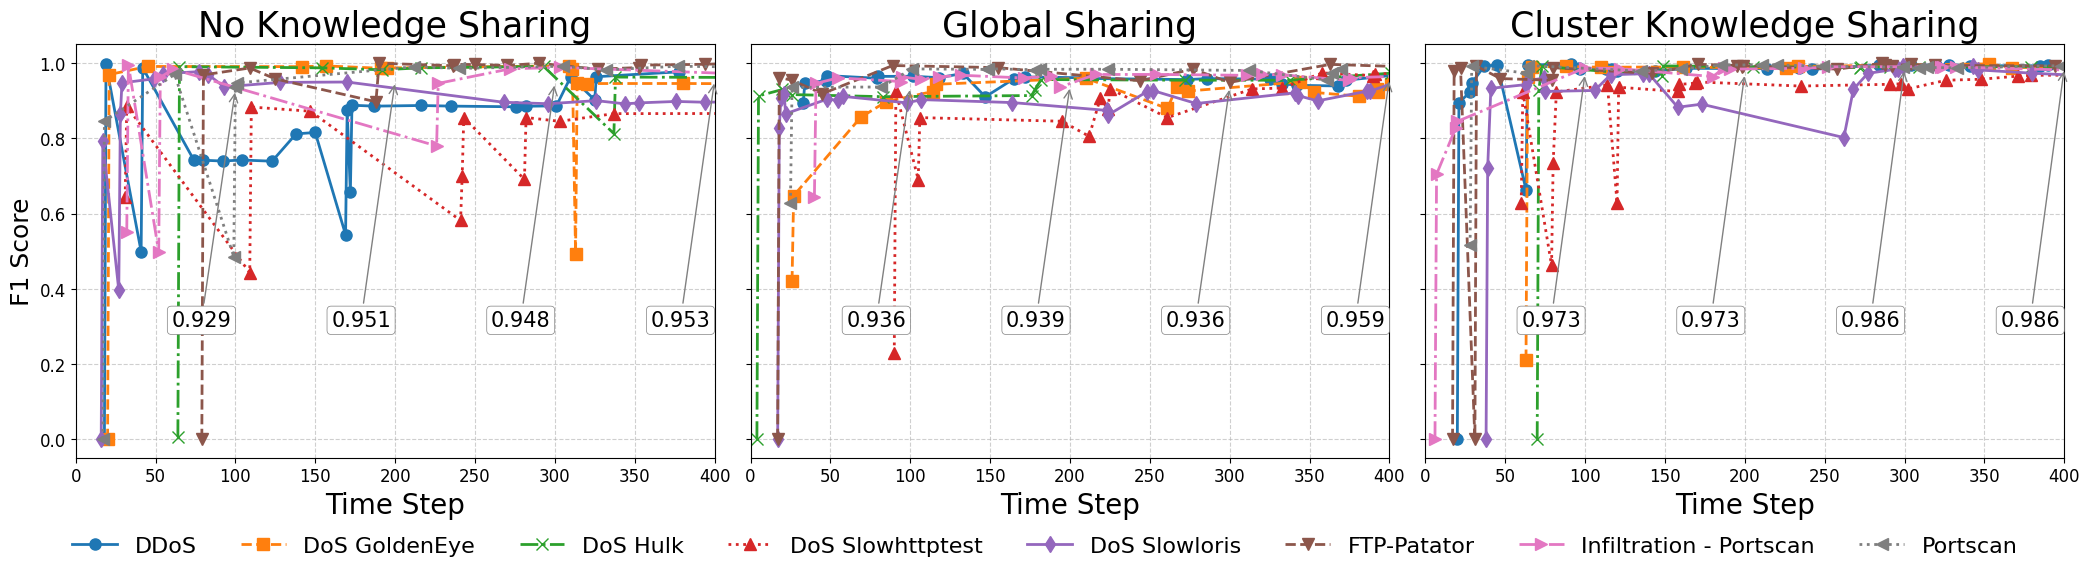

In [182]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attack_performance_subplots_shared_legend(attack_avg_perfomance_list):
    fig, axs = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
    linestyles = ['-', '--', '-.', ':']
    markers = ['o', 's', 'x', '^', 'd', 'v', '>', '<', 'P', '*']
    run_names = ["No Knowledge Sharing", "Global Sharing", "Cluster Knowledge Sharing"]
    all_handles = []
    all_labels = []

    for run_idx, (attack_avg_perfomance, ax) in enumerate(zip(attack_avg_perfomance_list, axs)):
        final_avg_f1 = []
        f1_at_steps = {step: [] for step in range(0, 501, 100)}  # to collect per-step f1s

        sorted_attacks = sorted(attack_avg_perfomance.items(), key=lambda x: x[0])

        for i, (attack, performance) in enumerate(sorted_attacks):
            if attack == "SSH-Patator":
                continue
            performance = np.array(performance, dtype=object)
            times = performance[:, 0].astype(int)
            f1s = performance[:, 2].astype(float)

            change_mask = np.ones_like(f1s, dtype=bool)
            change_mask[1:] = f1s[1:] != f1s[:-1]
            time_mask = times <= 500
            combined_mask = change_mask & time_mask

            times = times[combined_mask]
            f1s = f1s[combined_mask]

            final_avg_f1.append(f1s[-1])

            # For each step, record the last F1 score up to that time
            for step in f1_at_steps.keys():
                if np.any(times <= step):
                    f1_at_steps[step].append(f1s[times <= step][-1])

            line, = ax.plot(
                times,
                f1s,
                linestyle=linestyles[i % len(linestyles)],
                marker=markers[i % len(markers)],
                linewidth=2,
                markersize=8,
                label=attack
            )

            if run_idx == 0:
                all_handles.append(line)
                all_labels.append(attack)

        # Annotate mean F1 at each step
        for step, f1_list in f1_at_steps.items():
            if f1_list:  # Ensure it's not empty
                mean_f1 = np.mean(f1_list)
                ax.annotate(
                    f"{mean_f1:.3f}",
                    xy=(step, mean_f1),
                    xytext=(step-40, 0.3),
                    fontsize=15,
                    arrowprops=dict(arrowstyle="->", lw=1, color="gray"),
                    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", lw=0.5)
                )

        ax.set_title(f"{run_names[run_idx]}", fontsize=25)
        ax.set_xlabel("Time Step", fontsize=20)
        # ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(labelsize=12)
        ax.set_xlim(0,400)
        if run_idx == 0:
            ax.set_ylabel("F1 Score", fontsize=18)

        print(f"Mean F1 for Run {run_idx + 1}: {np.mean(final_avg_f1):.3f} ± {np.std(final_avg_f1):.3f}")

    # Common legend
    fig.legend(all_handles, all_labels, loc='lower center', ncol=9, fontsize=16, frameon=False, bbox_to_anchor=(0.5, -0.02))
    
    # fig.suptitle("Anomaly Detection Performance Over Time (3 Runs)", fontsize=30)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.show()


plot_attack_performance_subplots_shared_legend(attack_avg_perfomance_list)


### Epochs Comparison

In [11]:
from sklearn.metrics import accuracy_score, f1_score

acc_list = []
f1_list = []

for epochs in np.arange(1, 10, 2):
    # Initialize and train the model
    clf = PReNet(device='cuda', verbose=1, epochs=epochs)
    clf.fit(X_gm_train.to_numpy(), y=y_gm_train)
    
    # Predict on the training data
    y_pred = clf.predict(X_gm_test.to_numpy())
    
    # Calculate metrics
    acc = accuracy_score(y_gm_test, y_pred)
    f1 = f1_score(y_gm_test, y_pred, average='binary')  # Use 'binary' or 'weighted' based on your label type
    
    # Store the results
    acc_list.append((epochs, acc))
    f1_list.append((epochs, f1))
    
    print(f"Epochs: {epochs}, Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")


NameError: name 'X_gm_train' is not defined

### Entire Data Accuracy

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

acc_list = []
f1_list = []
X_gm_train, X_gm_test, y_gm_train, y_gm_test = preprocess_data(cicids_df)
# # Initialize and train the model
clf = PReNet(device='cuda', verbose=1, epochs=1, batch_size=64)
clf.fit(X_gm_train.to_numpy(), y=y_gm_train.values)



Start Training...
ensemble size: 1


KeyboardInterrupt: 

In [ ]:
y_pred = clf.predict(X_gm_test.to_numpy())

# Calculate metrics
acc = accuracy_score(y_gm_test, y_pred)
f1 = f1_score(y_gm_test, y_pred, average='binary')  # Use 'binary' or 'weighted' based on your label type
print(acc, f1)


0.9857167712510247 0.923649259942822


### Individual Attack Accuracy

In [ ]:
clf = global_model.clf

In [ ]:
atk_info_list = define_atk(atk_list, edge_area_list, cicids_df, benign_df)
atk_acc = {}
atk_f1 = {}
atk_scores = {}
for attack in atk_info_list.values():
    print(f"__{attack.name}__")
    _, X_test, _, y_test = preprocess_data(attack.data.copy())
    y_pred = clf.predict(X_test.to_numpy())

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')  # Use 'binary' or 'weighted' based on your label type    
    atk_acc[attack.name] = acc
    atk_f1[attack.name]=f1
    print(acc, f1)
    
    anomaly_scores = clf.decision_function(X_gm_test.to_numpy())
    atk_scores[attack.name] = anomaly_scores
    
    
    

__Portscan__
0.9528439759592324 0.7937964649697209
__DoS Hulk__
0.9821739403510031 0.9107028484746335
__DDoS__
0.9823961850290839 0.9117089379916271
__Infiltration - Portscan__
0.9344951982636446 0.6923882437809787
__DoS GoldenEye__
0.9887666527410296 0.9406280667320903
__FTP-Patator__
0.8738023542294004 0.16636528028933092
__DoS Slowloris__
0.9545066008167917 0.7909209951986033
__SSH-Patator__
0.8323497531012887 0.004291845493562232
__DoS Slowhttptest__
0.9651560926485397 0.8322017458777885


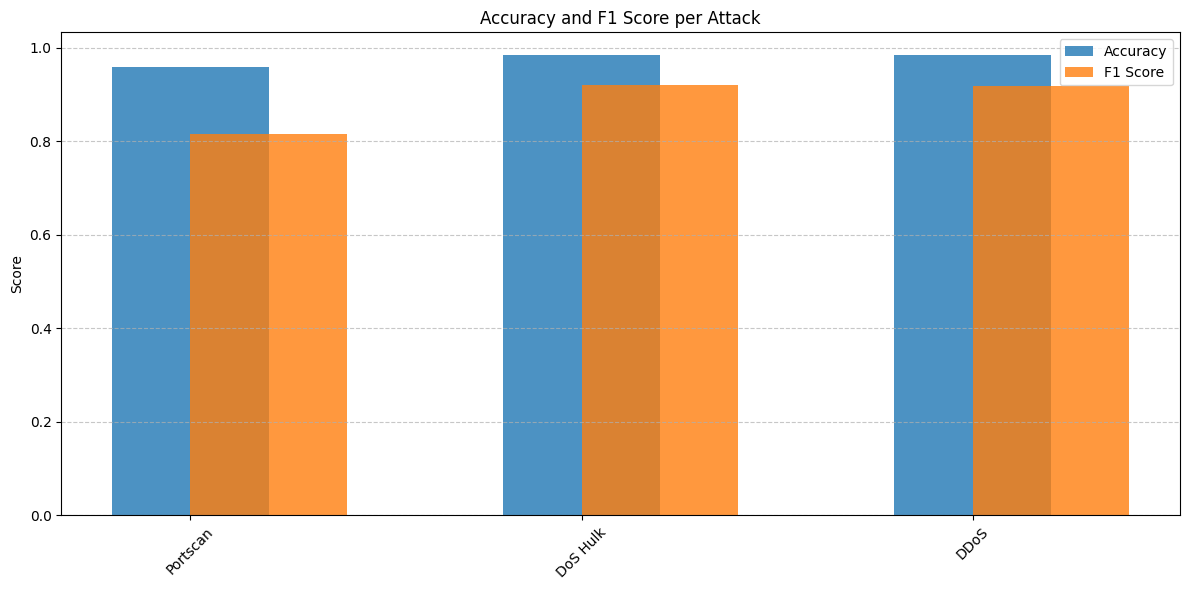

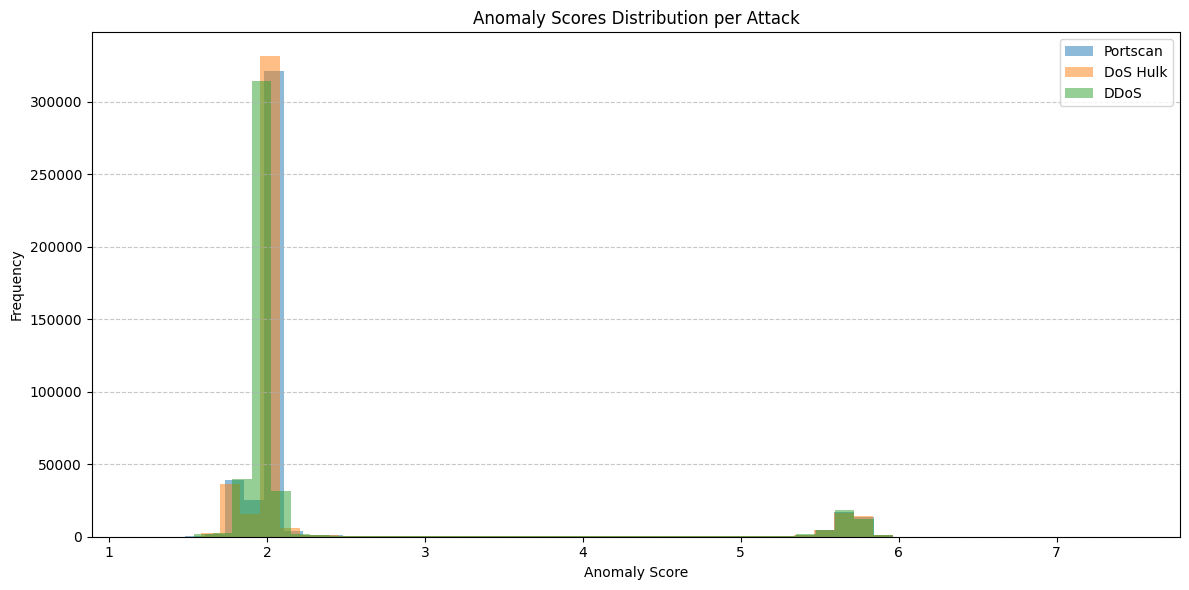

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy and F1 Score for each attack
def plot_metrics(atk_acc, atk_f1):
    attack_names = list(atk_acc.keys())
    accuracies = list(atk_acc.values())
    f1_scores = list(atk_f1.values())

    x = range(len(attack_names))

    plt.figure(figsize=(12, 6))
    plt.bar(x, accuracies, width=0.4, label="Accuracy", align='center', alpha=0.8)
    plt.bar(x, f1_scores, width=0.4, label="F1 Score", align='edge', alpha=0.8)

    plt.xticks(x, attack_names, rotation=45)
    plt.ylabel("Score")
    plt.title("Accuracy and F1 Score per Attack")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Plot anomaly scores for each attack
def plot_anomaly_scores(atk_scores):
    plt.figure(figsize=(12, 6))

    for attack, scores in atk_scores.items():
        plt.hist(scores, bins=50, alpha=0.5, label=f"{attack}")

    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.title("Anomaly Scores Distribution per Attack")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Call the functions
plot_metrics(atk_acc, atk_f1)
plot_anomaly_scores(atk_scores)


<Figure size 1000x600 with 0 Axes>

(array([1.000e+00, 0.000e+00, 0.000e+00, 7.000e+00, 4.000e+00, 2.400e+01,
        1.900e+01, 4.900e+01, 1.830e+02, 1.010e+02, 6.630e+02, 2.290e+02,
        1.590e+03, 1.729e+03, 2.041e+03, 4.953e+03, 1.292e+03, 7.192e+03,
        2.695e+03, 5.684e+03, 4.922e+03, 1.984e+03, 3.829e+03, 8.820e+02,
        1.753e+03, 7.460e+02, 5.080e+02, 4.460e+02, 3.260e+02, 2.460e+02,
        2.260e+02, 1.930e+02, 1.160e+02, 1.110e+02, 7.100e+01, 4.200e+01,
        2.300e+01, 1.100e+01, 9.000e+00, 2.000e+00, 2.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 1.000e+00, 2.000e+00,
        0.000e+00, 2.000e+00, 1.000e+00, 2.000e+00, 2.000e+00, 1.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e+00,
        5.000e+00, 9.000e+00, 1.100e+0

(array([  1.,   2.,   0.,  12.,   3.,  20.,  26.,  29.,  50.,  19.,  85.,
         22.,  83.,  34.,  68.,  47.,  35.,  49.,  36.,  26.,  25.,  27.,
         31.,  30.,  22.,  21.,  16.,  21.,   6.,   2.,   2.,   0.,   2.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   1.,   0.,   1.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   1.,   0.,   0.,   1.,   6.,  13.,  17.,  37.,  70.,
        102., 119., 186., 212., 294., 346., 388., 374., 377., 302., 258.,
        208., 131.,  98.,  57.,  23.,  11.,   8.,   5.,   1.,   0.,   0.,
          2.]),
 array([1.12100303, 1.17780782, 1.23461261, 1.29141739, 1.34822218,
        1.40502697, 1.46183175, 1.51863654, 1.57544133, 1.63224611,
        1.6890509 , 1.74585569, 1.80266047, 1.85946526, 1.91627005,
        1.97307484, 2.02987962, 2.08668441, 2.1434892 , 2.20029398,
        2.25709877, 2.31390356, 2.37070834, 2.

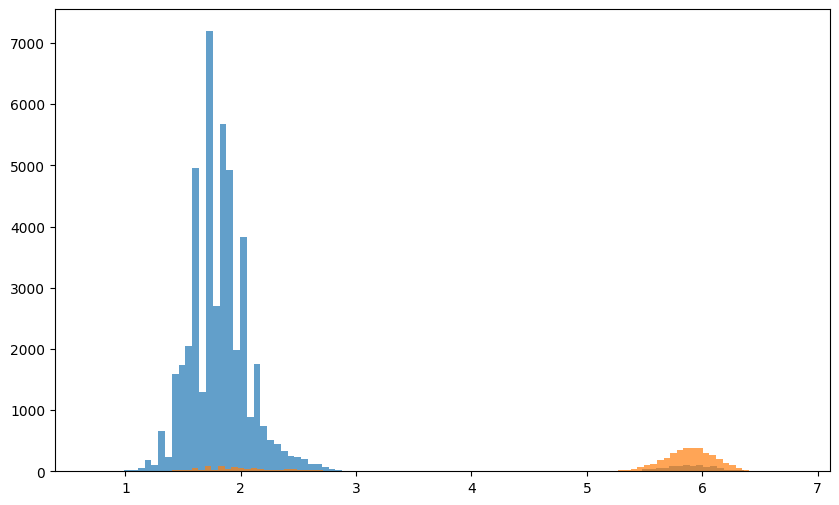

In [ ]:
scores_inliers = anomaly_scores[y_gm_test == 0]  # Assuming '0' is the label for inliers
scores_outliers = anomaly_scores[y_gm_test == 1]  # Assuming '1' is the label for outliers
# Create the plots
plt.figure(figsize=(10, 6))  # Set the figure size

# Plot for inliers
plt.hist(scores_inliers, bins=100, alpha=0.7, label='Inliers')

# Plot for outliers
plt.hist(scores_outliers, bins=100, alpha=0.7, label='Outliers')

Functions

In [ ]:

def plot_graph_scenario(metrics_dict, supervision_rate_list):
    fig, axes = plt.subplots(2,1,figsize=(14, 8))  # Create a figure and a set of subplots.
    ax_n = 0
    for metric_type in metrics_dict:
        curr_ax = axes[ax_n]
        ax_n +=1

        # Assuming metrics_dict['roc_auc'] contains the ROC AUC values for each IP
        ips = list(metrics_dict[metric_type].keys())
        n_ips = len(ips)
        n_supervision_rates = len(supervision_rate_list)

        # Create a numpy array to hold the ROC AUC values
        roc_aucs = np.zeros((n_ips, n_supervision_rates))
        
        for i, ip in enumerate(ips):
            for j, sr in enumerate(supervision_rate_list):
                roc_aucs[i, j] = metrics_dict[metric_type][ip][sr]

        # Create the bar width
        bar_width = 0.15
        index = np.arange(n_ips)

        # Plot bars for each supervision rate
        for j, sr in enumerate(supervision_rate_list):
            curr_ax.bar(index + j * bar_width, roc_aucs[:, j], bar_width, label=f'Supervision Rate: {sr}')

        curr_ax.set_title('ROC AUC Comparison by IP and Supervision Rate')
        curr_ax.set_xlabel('IP Address')
        curr_ax.set_ylabel('AUC')
        curr_ax.set_xticks(index + bar_width * (n_supervision_rates - 1) / 2)
        curr_ax.set_xticklabels(ips, rotation=45)
        curr_ax.legend()
        curr_ax.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
from functools import partial
from modAL.batch import uncertainty_batch_sampling

def lm_eval_2(Xgmm_test_dvc, gm_pred, lm_clf):
    train_perc = 0.6
    Xlm_train, Xlm_test, ylm_train, ylm_test = train_test_split(Xgmm_test_dvc, 
                                                        gm_pred, 
                                                        test_size=1 - train_perc, 
                                                        shuffle=True, 
                                                        stratify=gm_pred, 
                                                        random_state=42)    
    if lm_clf == "Comittee":
        # initializing Committee members
        n_members = 3
        learner_list = list()
        for member_idx in range(n_members):

            # initializing learner
            learner = ActiveLearner(
                estimator=RandomForestClassifier(),
                X_training=Xlm_train, y_training=ylm_train,
            )
            learner_list.append(learner)        
        lm_clf = Committee(learner_list=learner_list)
        predictions = lm_clf.predict(Xlm_test)    
    else:
        # Train the classifier on the training data
        lm_clf.fit(Xlm_train, ylm_train)    
        
        predictions = lm_clf.predict(Xlm_test)

        
    # Evaluate accuracy
    accuracy = accuracy_score(ylm_test, predictions)
    print(f"Accuracy: {accuracy}")
    return accuracy, lm_clf, Xlm_train, ylm_train
# Read the csv and clean it
def train_gm(Xgm_train_scaled, y_train, supervision_rate, model):


    # Prepare labels for semi-supervised learning
    idx = np.where(y_train == 1)[0]
    y = np.zeros_like(y_train.values)
    y = set_supervised_label(supervision_rate, anomaly_rate, y, idx)
    # Train the model
    path = f"gm_1_{supervision_rate}.pkl"
    if os.path.exists(path):
        with open(path, 'rb') as f:
            clf = pickle.load(f)
    else:
        clf = model(device='cuda', verbose=1, epochs=1)
        clf.fit(X=Xgm_train_scaled.to_numpy(), y=y_train)  
            
            # with open(path, 'wb') as f:
                # pickle.dump(clf, f)
    return clf
def train_lm(victim_IP, Xgmm_test, y_test, scaler, gm_clf,lm_clf, method = "Normal"):
    # Load Model Instead      
    # dropping_cols = ['Protocol', 'id', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP', 
    #                 'Dst Port', 'Timestamp', 'Dvc Label']            
    # Create a fresh copy of the DataFrame for each IP and supervision rate
    roc_auc, curr_X_test_scaled, gm_pred, gm_opt_threshold = perform_inference(Xgmm_test, y_test, dropping_cols, scaler, gm_clf)
    print(f"gm_opt_threshold is {gm_opt_threshold}")
    acc, updated_lm_clf, Xlm_train, Ylm_train = lm_eval_2(curr_X_test_scaled, gm_pred, lm_clf)
    return updated_lm_clf, gm_opt_threshold, Xlm_train, Ylm_train



# Perform New Attack Classification using Local Model (Obtain)
def new_attacks_inference(lm_clf, Xnew_train, ynew_train, scaler):

        cart_predictions = lm_clf.predict(Xnew_train)
        # Evaluate accuracy
        accuracy = accuracy_score(ynew_train, cart_predictions)
        print(f"Accuracy before update: {accuracy}")
        
        # Get Confidence Point
        # Get the indices of the samples where the actual label doesn't match the predicted label
        mismatch_indices = [i for i, (actual, cart_predictions) in enumerate(zip(ynew_train, cart_predictions)) if actual != cart_predictions]

        uncertain_count = 0
        cart_probabilities = lm_clf.predict_proba(Xnew_train)

        return accuracy, cart_probabilities, mismatch_indices 

def active_learning_query(lm_clf, Xnew_train, ynew_train, scaler):
    pass
    #Use Stream-Based Sampling, however instead of 1 by 1, get the whole pool

        # X_pool = Xnew_train.copy()
        # y_pool = ynew_train.copy()
        # for idx in range(n_queries):
        #     query_idx, query_instance = lm_clf.query(X_pool)
        #     lm_clf.teach(
        #         X=X_pool[query_idx].reshape(1, -1),
        #         y=y_pool[query_idx].reshape(1, )
        #     )
        #     performance_history.append(lm_clf.score())
        #     # remove queried instance from pool
        #     X_pool = np.delete(X_pool, query_idx, axis=0)
        #     y_pool = np.delete(y_pool, query_idx)     
        # predictions = lm_clf.predict(X_pool)     
        
    

# Forward Low confidence data to GM and Label (Get GM Accuracy)
def get_low_confidence_data(cart_probabilities, mismatch_indices, threshold=1):
    if threshold == 1:
        forward_gm_idx = np.where((cart_probabilities[:, 0] != threshold) & (cart_probabilities[:, 0] !=  threshold))
    else: 
        forward_gm_idx = np.where((cart_probabilities[:, 0] > threshold) & (cart_probabilities[:, 0] <  1-threshold))
    print(f"Total Uploaded Data {len(forward_gm_idx[0])}")
    # How many Misclassified data is inconfident
    set_mismatch_indices = set(list(mismatch_indices))
    set_forward_gm_idx = set(forward_gm_idx[0].tolist())
    x = len(set_mismatch_indices.intersection(set_forward_gm_idx))
    print(f"Percentage of misclassied data that is uploaded: {x/len(mismatch_indices)}")
    print(f"Total Data Uploaded: {len(forward_gm_idx[0])/len(cart_probabilities)}")
    # print(f"Correctly Detected / Uploaded data: {(x/len(forward_gm_idx[0]))}")  
    return forward_gm_idx

# Upload to label and Perform Training on CART_Classifier
def upload_gm(X_forward, y_forward, gm_clf, lm_clf, gm_opt_threshold, orig_Xlm_train, orig_Ylm_train):
    anomaly_scores = gm_clf.decision_function(X=X_forward)
    initial_gm_pred = np.where(anomaly_scores > gm_opt_threshold, 1,0)
    accuracy = accuracy_score(y_forward, initial_gm_pred)
    print(f'Accuracy of GM before update: {accuracy}')
    
    # Convert numpy arrays to DataFrames
    X_forward_df = pd.DataFrame(X_forward, columns = orig_Xlm_train.columns )
    y_forward_df = pd.DataFrame(np.zeros(initial_gm_pred.shape[0]), columns=["Label"])

    # Concatenate with original DataFrames
    Xtrain = pd.concat([pd.DataFrame(orig_Xlm_train), X_forward_df], axis=0)
    Ytrain = pd.concat([pd.DataFrame(orig_Ylm_train, columns=["Label"]), y_forward_df])
    Xtrain.columns = orig_Xlm_train.columns
    # return Xtrain, Ytrain
    # Update GM
    gm_clf = train_gm(orig_Xlm_train, orig_Ylm_train, supervision_rate, PReNet)
    # Inference using updated GM
    anomaly_scores = gm_clf.decision_function(X=X_forward)
    updated_gm_pred = np.where(anomaly_scores > gm_opt_threshold, 1,0)
    accuracy = accuracy_score(y_forward, updated_gm_pred)
    print(f'Accuracy of GM after update: {accuracy}')  
    
    Ytrain = pd.concat([pd.DataFrame(orig_Ylm_train, columns=["Label"]), pd.DataFrame(updated_gm_pred, columns=["Label"])])  
    lm_clf = XGBClassifier(objective='binary:logistic', n_estimators=100, learning_rate=0.1)
    # continued_model.fit(X_forward_df, y_forward_df, xgb_model=lm_clf.get_booster())    
    # continued_model.fit(Xtrain, Ytrain)
    lm_clf.fit(Xtrain, Ytrain)
    return lm_clf
# Evaluate Accuracy with new attack data
def eval_updated_lm(Xnew_test, ynew_test, new_lm_clf):
    pred = new_lm_clf.predict(Xnew_test)
    acc = accuracy_score(ynew_test, pred)
    print(f'Accuracy of updated LM: {acc}')


ModuleNotFoundError: No module named 'modAL'

In [ ]:
# Read the csv and clean it
def eval_model_unsupervised(improved_df, supervision_rate_list, model, victim_IP):
    anomaly_rate = 0.05
    metrics_dict = {
        'roc_auc': {ip : {sr : 0 for sr in supervision_rate_list} for ip in victim_IP}
    }
    X_train, X_test, y_train, y_test, scaler = process_dataset(improved_df, anomaly_rate)

    for supervision_rate in supervision_rate_list:
        # Prepare labels for semi-supervised learning
        idx = np.where(y_train == 1)[0]
        y = np.zeros_like(y_train.values)

        y = set_supervised_label(supervision_rate, anomaly_rate, y, idx)
            
        dropping_cols = ['Protocol', 'id', 'Flow ID', 'Src IP', 'Src Port', 'Dst IP', 
                        'Dst Port', 'Timestamp', 'Dvc Label']
        X_train.drop(dropping_cols, axis = 1, inplace = True)     
        
        X_train_scaled = scaler.fit_transform(X_train)
        X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns) 
        
        # Train the model
        clf = model(device='cuda', verbose=1, epochs=1)
        clf.fit(X=X_train_scaled.to_numpy(), y=y)        
        
        for curr_ip in victim_IP:
            # Create a fresh copy of the DataFrame for each IP and supervision rate

            roc_auc = perform_inference(X_test, y_test, curr_ip, dropping_cols, scaler, clf)
            # Store metrics
            metrics_dict['roc_auc'][curr_ip][supervision_rate] += roc_auc 

    return metrics_dict


# Fixing Accuracy

In [ ]:
from sklearn import metrics
def get_score(y_true, y_pred):
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  confusion_matrix = metrics.confusion_matrix(y_true, y_pred)

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(confusion_matrix)
  
# Read the csv and clean it
  
  
df = read_csv()
df = pd.concat([df[df['Label'] == 'BENIGN'], df[df['Label'] != 'BENIGN'].sample(frac=0.3, random_state=42)]) 
ratio = df.loc[df["Label"] == "BENIGN"].shape[0]/ df.loc[df["Label"] != "BENIGN"].shape[0]
print(f'Ratio of Benign to Anomaly is {ratio} : 1')
def eval_model_unsupervised(supervision_rate_list, model):
  anomaly_rate = 1.0
  for supervision_rate in supervision_rate_list:
    # supervision = False
    improved_df = df.copy()


    X_train, X_test, y_train, y_test = preprocess_data(improved_df)
    # Start Training
    idx = np.where(y_train==1)[0]
    y = np.zeros_like(y_train.values)
    if supervision_rate == 0:
      print(f"UNSUPERVISED, Sampling Rate = {anomaly_rate}")
      y[idx[:2]] = 1
    else:
      print(f"SEMI SUPERVISED, Sampling Rate = {anomaly_rate}, Supervision = {supervision_rate}")
      idx = np.random.choice(idx, size=int(supervision_rate*len(idx)), replace=False)
      y[idx] = 1
    
    clf = model( device = 'cuda', verbose=1, epochs=1)
    clf.fit(X=X_train.to_numpy(), y = y)
    # pred = clf.predict(X_test.to_numpy())
    anomaly_scores = clf.decision_function(X_test.to_numpy())

    fpr, tpr, _ = roc_curve(y_test, anomaly_scores)
    precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores)
    opt_threshold = get_optimal_threshold(precision, recall, thresholds)
    pred = np.where(anomaly_scores > opt_threshold, 1,0)
    accuracy = accuracy_score(y_test, pred)
    get_score(pred, y_test)
    

supervision_rate_list = [1.0, 0.5, 0.25, 0.1, 0.05, 0.0]

model = PReNet
eval_model_unsupervised(supervision_rate_list, model)


dataset shape (2099976, 91)
zero variance columns [] dropped
shape after removing zero variance columns: (2099976, 91)
5 rows dropped
shape after removing nan: (2099971, 91)
shape after dropping duplicates: (2099971, 91)
columns which have identical values [] dropped
shape after removing identical value columns: (2099971, 91)
SEMI SUPERVISED, Sampling Rate = 1.0, Supervision = 1.0
Start Training...
ensemble size: 1
epoch  1, training loss: 0.135584, time: 276.3s
Start Inference on the training data...
Accuracy: 0.9964
Precision: 0.9867
Recall: 0.9981
F1 Score: 0.9924
[[1354556    5696]
 [    803  423921]]
SEMI SUPERVISED, Sampling Rate = 1.0, Supervision = 0.5
Start Training...
ensemble size: 1


KeyboardInterrupt: 